In [ ]:
import geopandas as gpd

# Load SIMD file 
simd = gpd.read_file("/Users/xrysa/Desktop/MSc_in_Urban_Analytics/Dissertation/DATA/SG_SIMD_2020_raw 2/SG_SIMD_2020.shp")

# Filter for Inverclyde and Argyll and Bute
study_simd = simd[simd["LAName"].isin(["Inverclyde", "Argyll and Bute"])]


study_boundary = study_simd.copy()
# Dissolve into single boundary polygon
study_boundary_outline = study_simd.dissolve()

# Save boundary for reuse in clipping other layers
study_boundary.to_file("study_boundary.shp")

print(f"Boundary CRS: {study_boundary.crs}")
print(f"Boundary shape: {study_boundary.shape}")

all_lanames = study_boundary["LAName"].unique()

print(all_lanames)

Error in callback <bound method PositronShell._handle_pre_run_cell of <positron.positron_ipkernel.PositronShell object at 0x10c38fb60>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 3509bbd20, raw_cell="import geopandas as gpd

# Load your SIMD file fir.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/xrysa/Desktop/MSc_in_Urban_Analytics/Dissertation/Flooding_finalised.ipynb#W0sZmlsZQ%3D%3D>,),kwargs {}:


KeyboardInterrupt: 

In [ ]:
import geopandas as gpd
import pandas as pd

# Read SIMD shapefile
simd = gpd.read_file(
    "/Users/xrysa/Desktop/MSc_in_Urban_Analytics/Dissertation/DATA/SG_SIMD_2020_raw 2/SG_SIMD_2020.shp"
)

# Filter for Inverclyde and Argyll and Bute
Inverclyde_simd = simd[simd["LAName"] == "Inverclyde"].copy()
Argyll_simd = simd[simd["LAName"] == "Argyll and Bute"].copy()

# Reproject to a CRS in metres
Inverclyde_simd = Inverclyde_simd.to_crs("EPSG:27700")
Argyll_simd = Argyll_simd.to_crs("EPSG:27700")

# Create a 30 km buffer around Inverclyde
buffer_10km = Inverclyde_simd.geometry.buffer(10000)
buffer_gdf = gpd.GeoDataFrame(geometry=[buffer_10km.union_all()], crs=Inverclyde_simd.crs)

# Clip Argyll and Bute to the buffer
argyll_clipped = gpd.clip(Argyll_simd, buffer_gdf)

# Combine with Inverclyde
study_area = pd.concat([Inverclyde_simd, argyll_clipped], ignore_index=True)
study_area = gpd.GeoDataFrame(study_area, crs=Inverclyde_simd.crs)

# Dissolve to one boundary

study_area_10Kmbuffer_dissolved = study_area.dissolve()

# Save outputs
buffer_gdf.to_file("inverclyde_buffer_10km.shp")
argyll_clipped.to_file("argyll_clipped_to_inverclyde_buffer.shp")
study_area.to_file("study_area_10kmbuffer.shp")
study_area_10Kmbuffer_dissolved.to_file("study_area_10Kmbuffer_dissolved.shp")

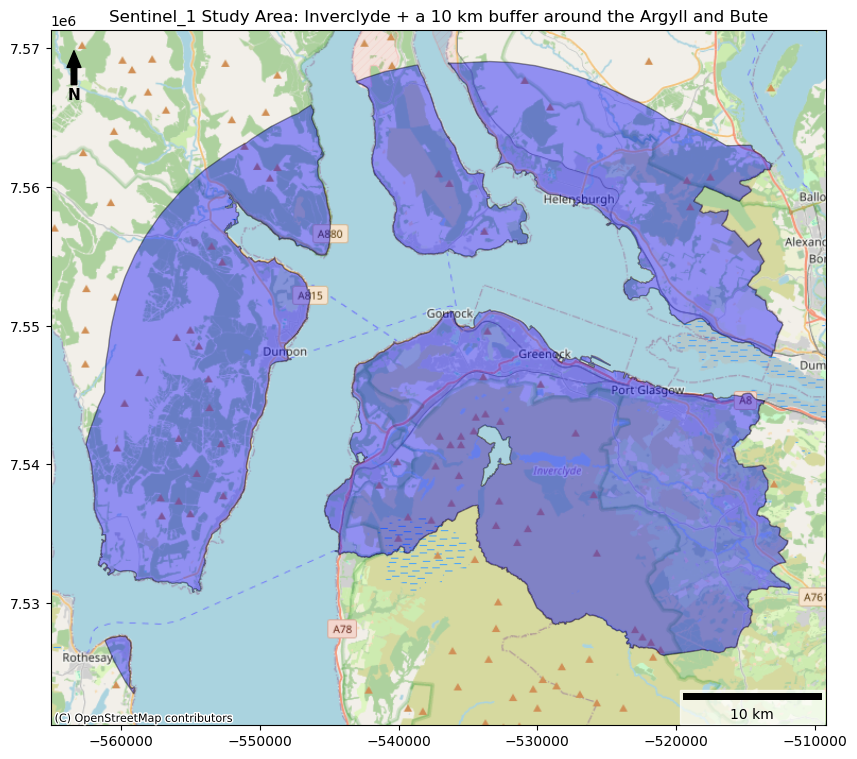

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
from matplotlib_scalebar.scalebar import ScaleBar

# Read shapefile
gdf = gpd.read_file("study_area_10Kmbuffer_dissolved.shp").to_crs(epsg=3857)


# Plot
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, color="blue", alpha=0.4, edgecolor="black")
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
ax.add_artist(ScaleBar(1, units="m", location="lower right", box_alpha=0.7))
ax.annotate(
    "N", xy=(0.03, 0.97), xytext=(0.03, 0.90),
    xycoords="axes fraction",
    arrowprops=dict(facecolor="black", width=4, headwidth=10),
    ha="center", fontsize=11, fontweight="bold",
)
plt.title("Sentinel_1 Study Area: Inverclyde + a 10 km buffer around the Argyll and Bute")
plt.show()

In [ ]:
import fiona
fiona.listlayers("/Users/xrysa/Desktop/MSc_in_Urban_Analytics/Dissertation/DATA/SEPA_River_Flood_Maps_v3_0/Data/FRM_River_Flood_Hazard_Layers_v3_0.gdb")

['FRM_FH_RIVER_DEPTH_H',
 'FRM_FH_RIVER_EXTENT_H',
 'FRM_FH_RIVER_VELOCITY_H',
 'FRM_FH_RIVER_VELOCITY_DIRECTION_H',
 'FRM_FH_RIVER_DEPTH_M',
 'FRM_FH_RIVER_EXTENT_M',
 'FRM_FH_RIVER_VELOCITY_M',
 'FRM_FH_RIVER_VELOCITY_DIRECTION_M',
 'FRM_FH_RIVER_DEPTH_L',
 'FRM_FH_RIVER_EXTENT_M_CC',
 'FRM_FH_RIVER_VELOCITY_M_CC',
 'FRM_FH_RIVER_VELOCITY_DIRECTION_M_CC',
 'FRM_FH_RIVER_DATA_NOT_AVAILABLE_M_CC']

/opt/anaconda3/envs/spatial-regression/lib/python3.14/site-packages/pyogrio/raw.py:200: RuntimeWarning: organizePolygons() received a polygon with more than 100 parts. The processing may be really slow.  You can skip the processing by setting METHOD=SKIP, or only make it analyze counter-clock wise parts by setting METHOD=ONLY_CCW if you can assume that the outline of holes is counter-clock wise defined
  return ogr_read(


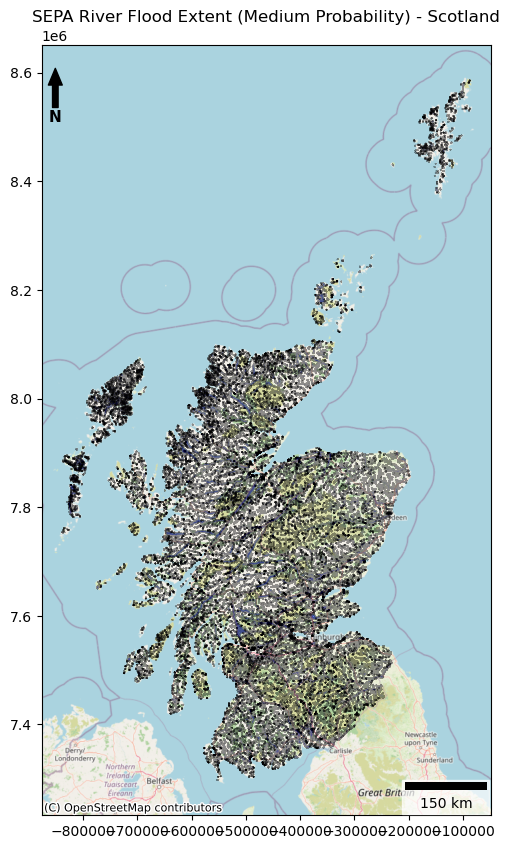

In [ ]:
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt

# Read from GDB and specify the layer name inside the geodatabase
gdf = gpd.read_file("/Users/xrysa/Desktop/MSc_in_Urban_Analytics/Dissertation/DATA/SEPA_River_Flood_Maps_v3_0/Data/FRM_River_Flood_Hazard_Layers_v3_0.gdb", layer="FRM_FH_RIVER_EXTENT_M")

# Reproject to Web Mercator as it required for basemap
gdf = gdf.to_crs(epsg=3857)

# Plot
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, color="blue", alpha=0.4, edgecolor="black")
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
ax.add_artist(ScaleBar(1, units="m", location="lower right", box_alpha=0.7))
ax.annotate(
    "N", xy=(0.03, 0.97), xytext=(0.03, 0.90),
    xycoords="axes fraction",
    arrowprops=dict(facecolor="black", width=4, headwidth=10),
    ha="center", fontsize=11, fontweight="bold",
)
plt.title("SEPA River Flood Extent (Medium Probability) - Scotland")
plt.show()

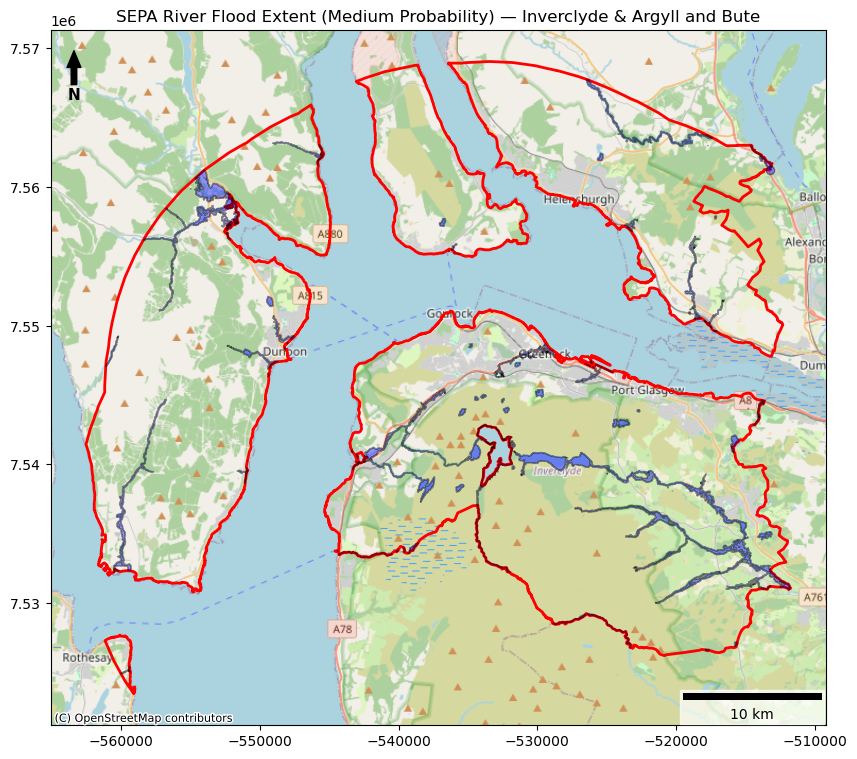

In [ ]:
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt

# Read saved study boundary
study_area = gpd.read_file("study_area_10Kmbuffer_dissolved.shp")

# Read SEPA flood layer
gdf = gpd.read_file("/Users/xrysa/Desktop/MSc_in_Urban_Analytics/Dissertation/DATA/SEPA_River_Flood_Maps_v3_0/Data/FRM_River_Flood_Hazard_Layers_v3_0.gdb", layer="FRM_FH_RIVER_EXTENT_M")

# Clip flood layer to study area
gdf = gdf.to_crs(study_area.crs)
gdf_clipped = gpd.clip(gdf, study_area)

# Reproject to Web Mercator for basemap
gdf_clipped = gdf_clipped.to_crs(epsg=3857)
study_area  = study_area.to_crs(epsg=3857)

# Plot
fig, ax = plt.subplots(figsize=(10, 10))
study_area.plot(ax=ax, color="none", edgecolor="red", linewidth=2)
gdf_clipped.plot(ax=ax, color="blue", alpha=0.4, edgecolor="black")
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
ax.add_artist(ScaleBar(1, units="m", location="lower right", box_alpha=0.7))
ax.annotate(
    "N", xy=(0.03, 0.97), xytext=(0.03, 0.90),
    xycoords="axes fraction",
    arrowprops=dict(facecolor="black", width=4, headwidth=10),
    ha="center", fontsize=11, fontweight="bold",
)
plt.title("SEPA River Flood Extent (Medium Probability) — Inverclyde & Argyll and Bute")
plt.show()

In [ ]:
import geopandas as gpd

# Read SEPA flood layer
gdf = gpd.read_file(
    "/Users/xrysa/Desktop/MSc_in_Urban_Analytics/Dissertation/DATA/"
    "SEPA_River_Flood_Maps_v3_0/Data/FRM_River_Flood_Hazard_Layers_v3_0.gdb",
    layer="FRM_FH_RIVER_EXTENT_M"
)

# Confirm it is vector polygon data
print("Geometry type:")
print(gdf.geom_type.value_counts())
print()

# Coordinate reference system as it matters for rasterisation later
print("CRS:", gdf.crs)
print()

# Attribute columns 
print("Columns:", list(gdf.columns))
print()

# Number of features
print(f"Number of polygons: {len(gdf)}")
print()

# Extent of the layer
print("Bounding box (minx, miny, maxx, maxy):")
print(gdf.total_bounds)
print()

# Sample of attribute values 
print("First 5 rows:")
print(gdf.head())
print()

# Polygon size distribution, like "resolution"
areas = gdf.geometry.area  
print("Polygon area statistics (square metres if CRS is OSGB):")
print(areas.describe())
print()

# Approximate "characteristic length scale" of the polygons:square root of median area as a rough indicator of feature size
import numpy as np
char_length = np.sqrt(areas.median())
print(f"Characteristic length scale (√median area): {char_length:.1f} m")

Geometry type:
MultiPolygon    47093
Name: count, dtype: int64

CRS: EPSG:27700

Columns: ['MAP_TYPE', 'SOURCE', 'METRIC', 'PROB', 'BAND_DESC', 'GRIDCODE', 'SCENARIO', 'CCGRIDCODE', 'REFERENCE', 'VERSION', 'ISSUE_DATE', 'Shape_Length', 'Shape_Area', 'geometry']

Number of polygons: 47093

Bounding box (minx, miny, maxx, maxy):
[  64150.  534000.  467115. 1216600.]

First 5 rows:
  MAP_TYPE SOURCE  METRIC PROB    BAND_DESC  GRIDCODE     SCENARIO  \
0   Hazard  River  Extent    M  Appropriate         1  Present Day   
1   Hazard  River  Extent    M  Appropriate         1  Present Day   
2   Hazard  River  Extent    M  Appropriate         1  Present Day   
3   Hazard  River  Extent    M  Appropriate         1  Present Day   
4   Hazard  River  Extent    M  Appropriate         1  Present Day   

   CCGRIDCODE REFERENCE VERSION                ISSUE_DATE  Shape_Length  \
0         999    HA_001    v3_0 2025-02-25 00:00:00+00:00         100.0   
1         999    HA_001    v3_0 2025-02-25 00:0

In [ ]:
fiona.listlayers("/Users/xrysa/Desktop/MSc_in_Urban_Analytics/Dissertation/DATA/SEPA_Surface_Water_Flood_Maps_EXTENT_v3_0/Data/FRM_Surface_Water_Flood_Hazard_EXTENT_Layers_v3_0.gdb")

['FRM_FH_SURFACE_WATER_EXTENT_H', 'FRM_FH_SURFACE_WATER_EXTENT_L']

In [ ]:
import geopandas as gpd

study_area = gpd.read_file("study_area_10Kmbuffer_dissolved.shp")
bbox = tuple(study_area.to_crs(epsg=27700).total_bounds)

gdf = gpd.read_file(
    "/Users/xrysa/Desktop/MSc_in_Urban_Analytics/Dissertation/DATA/SEPA_Surface_Water_Flood_Maps_EXTENT_v3_0/Data/FRM_Surface_Water_Flood_Hazard_EXTENT_Layers_v3_0.gdb",
    layer="FRM_FH_SURFACE_WATER_EXTENT_H",
    bbox=bbox
)

gdf = gdf.to_crs(study_area.crs)
gdf_clipped = gpd.clip(gdf, study_area)

gdf_clipped = gdf_clipped[gdf_clipped.geometry.geom_type.isin(["Polygon", "MultiPolygon"])].copy()

gdf_clipped.to_file("sepa_surface_water_clipped.shp")
print(f"Done — saved {len(gdf_clipped)} features")

<positron-console-cell-10>:17: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
/opt/anaconda3/envs/spatial-regression/lib/python3.14/site-packages/pyogrio/raw.py:733: RuntimeWarning: Field ISSUE_DATE created as String field, though DateTime requested.
  ogr_write(
/opt/anaconda3/envs/spatial-regression/lib/python3.14/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'geom_Length' to 'geom_Lengt'
  ogr_write(


Done — saved 26510 features


In [2]:
import geopandas as gpd
import numpy as np

# Load SEPA
gdf = gpd.read_file(
    "/Users/xrysa/Desktop/MSc_in_Urban_Analytics/Dissertation/DATA/"
    "SEPA_River_Flood_Maps_v3_0/Data/FRM_River_Flood_Hazard_Layers_v3_0.gdb",
    layer="FRM_FH_RIVER_EXTENT_M"
)

study = gpd.read_file(
    "study_area_10Kmbuffer_dissolved.shp"
).to_crs(gdf.crs)


# Filter SEPA to polygons intersecting the study area
sepa_local = gpd.overlay(gdf, study, how='intersection')

print(f"SEPA polygons in your study area: {len(sepa_local)}")
print()

if len(sepa_local) > 0:
    areas = sepa_local.geometry.area
    print("Local polygon area statistics (m²):")
    print(areas.describe())
    print()

    char_length = np.sqrt(areas.median())
    print(f"Local characteristic length scale: {char_length:.1f} m")
    print()

    # Distribution of polygons by size class
    print("Polygon count by characteristic length:")
    for threshold in [5, 10, 20, 50, 100]:
        area_threshold = threshold ** 2
        n = (areas < area_threshold).sum()
        pct = 100 * n / len(sepa_local)
        print(f"  Below {threshold} m characteristic length: {n} polygons ({pct:.1f}%)")



SEPA polygons in your study area: 393

Local polygon area statistics (m²):
count    3.930000e+02
mean     2.461422e+04
std      2.235271e+05
min      9.090908e-05
25%      2.500000e+01
50%      9.931587e+01
75%      4.250000e+02
max      3.894295e+06
dtype: float64

Local characteristic length scale: 10.0 m

Polygon count by characteristic length:
  Below 5 m characteristic length: 52 polygons (13.2%)
  Below 10 m characteristic length: 200 polygons (50.9%)
  Below 20 m characteristic length: 292 polygons (74.3%)
  Below 50 m characteristic length: 343 polygons (87.3%)
  Below 100 m characteristic length: 358 polygons (91.1%)


/opt/anaconda3/envs/spatial-regression/lib/python3.14/site-packages/geopandas/tools/overlay.py:358: UserWarning: `keep_geom_type=True` in overlay resulted in 5 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  result = _collection_extract(result, geom_type, keep_geom_type_warning)


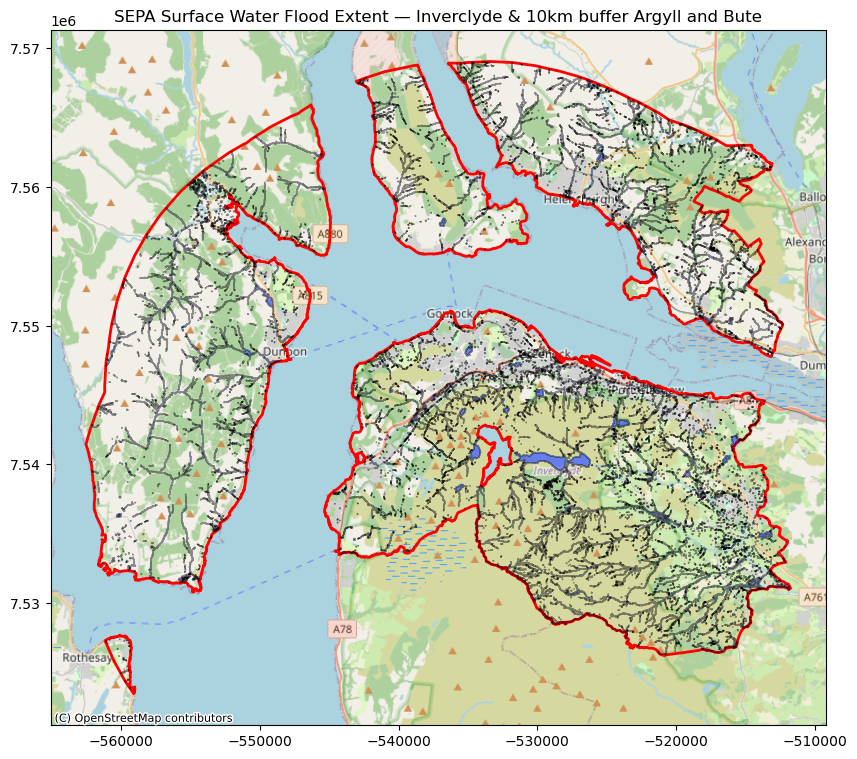

In [ ]:
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt

study_area  = gpd.read_file("study_area_10Kmbuffer_dissolved.shp").to_crs(epsg=3857)
gdf_clipped = gpd.read_file("sepa_surface_water_clipped.shp").to_crs(epsg=3857)



fig, ax = plt.subplots(figsize=(10, 10))
study_area.plot(ax=ax, color="none", edgecolor="red", linewidth=2)
gdf_clipped.plot(ax=ax, color="blue", alpha=0.4, edgecolor="black")
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
plt.title("SEPA Surface Water Flood Extent — Inverclyde & 10km buffer Argyll and Bute")
plt.show()

In [ ]:
fiona.listlayers("/Users/xrysa/Desktop/MSc_in_Urban_Analytics/Dissertation/DATA/SEPA_River_Flood_Maps_v3_0/Data/FRM_River_Flood_Hazard_Layers_v3_0.gdb")

['FRM_FH_RIVER_DEPTH_H',
 'FRM_FH_RIVER_EXTENT_H',
 'FRM_FH_RIVER_VELOCITY_H',
 'FRM_FH_RIVER_VELOCITY_DIRECTION_H',
 'FRM_FH_RIVER_DEPTH_M',
 'FRM_FH_RIVER_EXTENT_M',
 'FRM_FH_RIVER_VELOCITY_M',
 'FRM_FH_RIVER_VELOCITY_DIRECTION_M',
 'FRM_FH_RIVER_DEPTH_L',
 'FRM_FH_RIVER_EXTENT_M_CC',
 'FRM_FH_RIVER_VELOCITY_M_CC',
 'FRM_FH_RIVER_VELOCITY_DIRECTION_M_CC',
 'FRM_FH_RIVER_DATA_NOT_AVAILABLE_M_CC']

In [ ]:
import geopandas as gpd

study_area = gpd.read_file("study_area_10Kmbuffer_dissolved.shp")
bbox = tuple(study_area.to_crs(epsg=27700).total_bounds)

gdf = gpd.read_file(
    "/Users/xrysa/Desktop/MSc_in_Urban_Analytics/Dissertation/DATA/SEPA_River_Flood_Maps_v3_0/Data/FRM_River_Flood_Hazard_Layers_v3_0.gdb",
    layer="FRM_FH_RIVER_EXTENT_H",
    bbox=bbox
)

gdf = gdf.to_crs(study_area.crs)
gdf_clipped = gpd.clip(gdf, study_area)

gdf_clipped = gdf_clipped[gdf_clipped.geometry.geom_type.isin(["Polygon", "MultiPolygon"])].copy()

gdf_clipped.to_file("sepa_river_water_clipped.shp")
print(f"Done — saved {len(gdf_clipped)} features")

Done — saved 365 features


<positron-console-cell-14>:17: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
/opt/anaconda3/envs/spatial-regression/lib/python3.14/site-packages/pyogrio/raw.py:733: RuntimeWarning: Field ISSUE_DATE created as String field, though DateTime requested.
  ogr_write(
/opt/anaconda3/envs/spatial-regression/lib/python3.14/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'Shape_Length' to 'Shape_Leng'
  ogr_write(


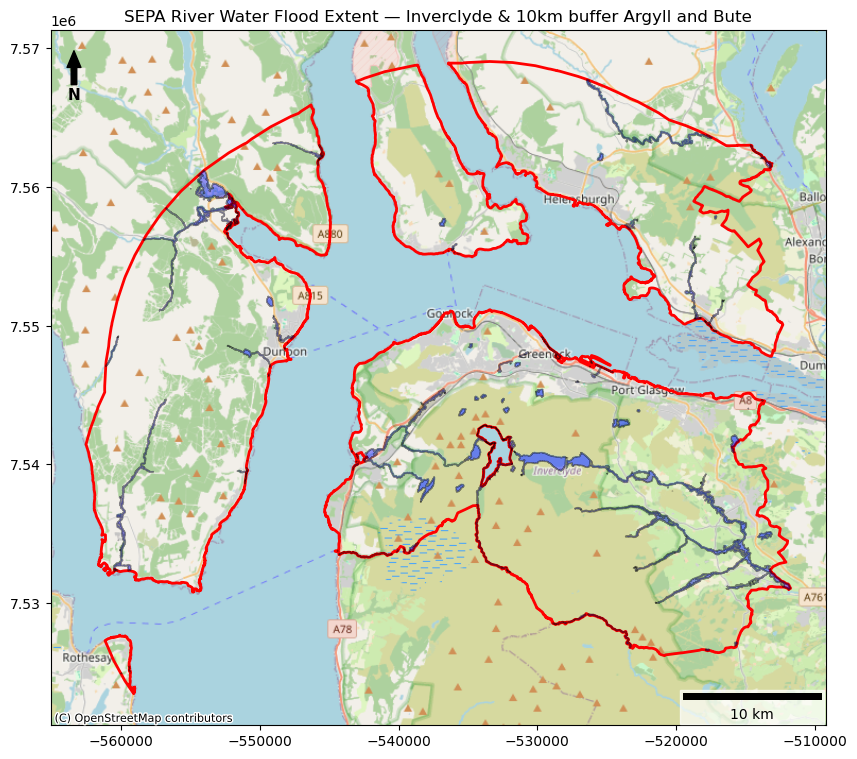

In [ ]:
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt

study_area  = gpd.read_file("study_area_10Kmbuffer_dissolved.shp").to_crs(epsg=3857)
gdf_clipped = gpd.read_file("sepa_river_water_clipped.shp").to_crs(epsg=3857)



fig, ax = plt.subplots(figsize=(10, 10))
study_area.plot(ax=ax, color="none", edgecolor="red", linewidth=2)
gdf_clipped.plot(ax=ax, color="blue", alpha=0.4, edgecolor="black")
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
ax.add_artist(ScaleBar(1, units="m", location="lower right", box_alpha=0.7))
ax.annotate(
    "N", xy=(0.03, 0.97), xytext=(0.03, 0.90),
    xycoords="axes fraction",
    arrowprops=dict(facecolor="black", width=4, headwidth=10),
    ha="center", fontsize=11, fontweight="bold",
)
plt.title("SEPA River Water Flood Extent — Inverclyde & 10km buffer Argyll and Bute")
plt.show()

<positron-console-cell-16>:27: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
/opt/anaconda3/envs/spatial-regression/lib/python3.14/site-packages/pyogrio/raw.py:733: RuntimeWarning: Field ISSUE_DATE created as String field, though DateTime requested.
  ogr_write(
/opt/anaconda3/envs/spatial-regression/lib/python3.14/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'Shape_Length' to 'Shape_Leng'
  ogr_write(


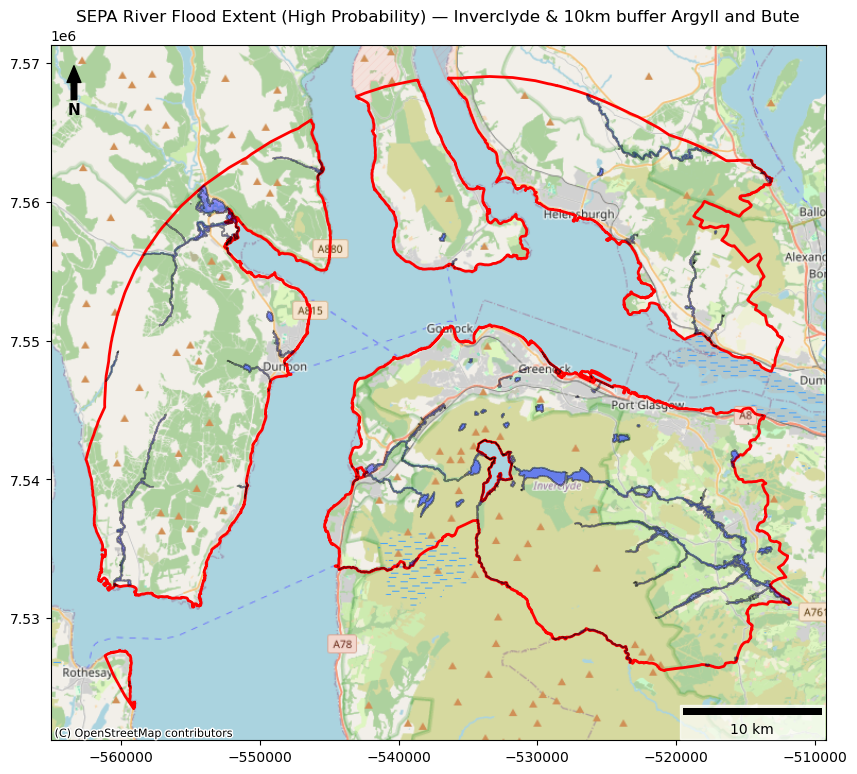

In [ ]:
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt


study_area = gpd.read_file("study_area_10Kmbuffer_dissolved.shp")

# Get bounding box of study area to use as spatial filter on load
bbox = tuple(study_area.to_crs(epsg=27700).total_bounds)  

# Read only the data within the bounding box, so it runs much faster
gdf = gpd.read_file(
    "/Users/xrysa/Desktop/MSc_in_Urban_Analytics/Dissertation/DATA/SEPA_River_Flood_Maps_v3_0/Data/FRM_River_Flood_Hazard_Layers_v3_0.gdb",
    layer="FRM_FH_RIVER_EXTENT_H",
    bbox=bbox
)

# Clip to study area boundary
gdf = gdf.to_crs(study_area.crs)
gdf_clipped = gpd.clip(gdf, study_area)

# Keep only polygon/multipolygon geometries
gdf_clipped = gdf_clipped[gdf_clipped.geometry.type.isin(["Polygon", "MultiPolygon"])].copy()


# Save the clipped file 
gdf_clipped.to_file("sepa_river_clipped.shp")

# Reproject to Web Mercator for basemap
gdf_clipped = gdf_clipped.to_crs(epsg=3857)
study_area  = study_area.to_crs(epsg=3857)

# Plot
fig, ax = plt.subplots(figsize=(10, 10))
study_area.plot(ax=ax, color="none", edgecolor="red", linewidth=2)
gdf_clipped.plot(ax=ax, color="blue", alpha=0.4, edgecolor="black")
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
ax.add_artist(ScaleBar(1, units="m", location="lower right", box_alpha=0.7))
ax.annotate(
    "N", xy=(0.03, 0.97), xytext=(0.03, 0.90),
    xycoords="axes fraction",
    arrowprops=dict(facecolor="black", width=4, headwidth=10),
    ha="center", fontsize=11, fontweight="bold",
)
plt.title("SEPA River Flood Extent (High Probability) — Inverclyde & 10km buffer Argyll and Bute")
plt.show()

In [ ]:
fiona.listlayers("/Users/xrysa/Desktop/MSc_in_Urban_Analytics/Dissertation/DATA/SEPA_Coastal_Flood_Maps_v3_0/Data/FRM_Coastal_Flood_Hazard_Layers_v3_0.gdb")

['FRM_FH_COASTAL_DATA_NOT_AVAILABLE_M_CC',
 'FRM_FH_COASTAL_DEPTH_H',
 'FRM_FH_COASTAL_DEPTH_L',
 'FRM_FH_COASTAL_DEPTH_M_CC',
 'FRM_FH_COASTAL_DEPTH_M',
 'FRM_FH_COASTAL_EXTENT_H',
 'FRM_FH_COASTAL_EXTENT_L',
 'FRM_FH_COASTAL_EXTENT_M_CC',
 'FRM_FH_COASTAL_EXTENT_M']

In [ ]:
import geopandas as gpd

study_area = gpd.read_file("study_area_10Kmbuffer_dissolved.shp")
bbox = tuple(study_area.to_crs(epsg=27700).total_bounds)

gdf = gpd.read_file(
    "/Users/xrysa/Desktop/MSc_in_Urban_Analytics/Dissertation/DATA/SEPA_Coastal_Flood_Maps_v3_0/Data/FRM_Coastal_Flood_Hazard_Layers_v3_0.gdb",
    layer="FRM_FH_COASTAL_EXTENT_H",
    bbox=bbox
)

gdf = gdf.to_crs(study_area.crs)
gdf_clipped = gpd.clip(gdf, study_area)

gdf_clipped = gdf_clipped[gdf_clipped.geometry.geom_type.isin(["Polygon", "MultiPolygon"])].copy()

gdf_clipped.to_file("sepa_coastal_water_clipped.shp")
print(f"Done — saved {len(gdf_clipped)} features")

Done — saved 1 features


<positron-console-cell-18>:17: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
/opt/anaconda3/envs/spatial-regression/lib/python3.14/site-packages/pyogrio/raw.py:733: RuntimeWarning: Field ISSUE_DATE created as String field, though DateTime requested.
  ogr_write(
/opt/anaconda3/envs/spatial-regression/lib/python3.14/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'Shape_Length' to 'Shape_Leng'
  ogr_write(


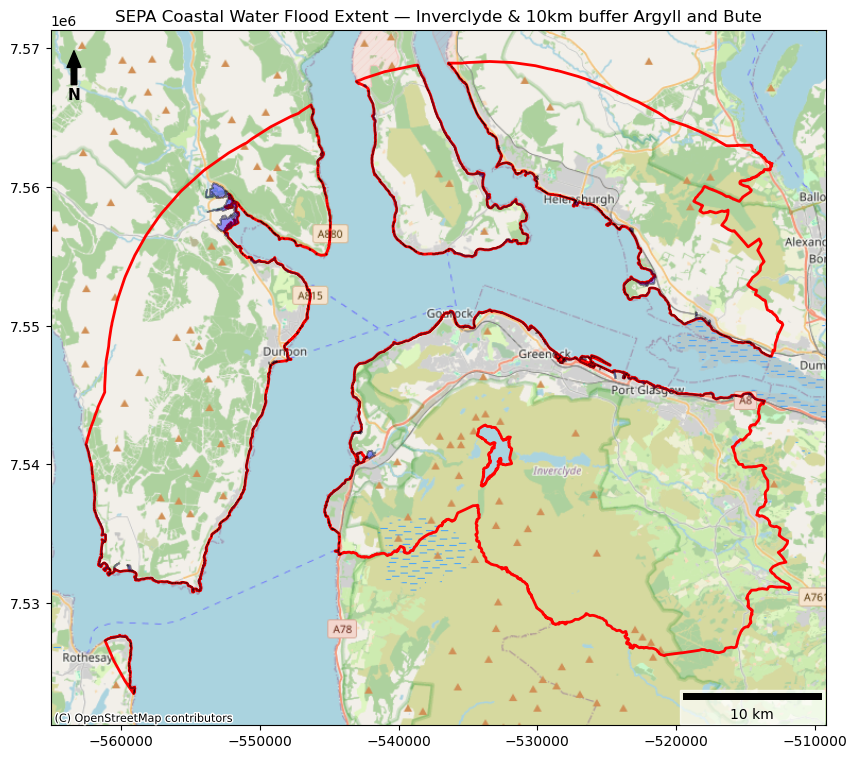

In [ ]:
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt

study_area  = gpd.read_file("study_area_10Kmbuffer_dissolved.shp").to_crs(epsg=3857)
gdf_clipped = gpd.read_file("sepa_coastal_water_clipped.shp").to_crs(epsg=3857)



fig, ax = plt.subplots(figsize=(10, 10))
study_area.plot(ax=ax, color="none", edgecolor="red", linewidth=2)
gdf_clipped.plot(ax=ax, color="blue", alpha=0.4, edgecolor="black")
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
ax.add_artist(ScaleBar(1, units="m", location="lower right", box_alpha=0.7))
ax.annotate(
    "N", xy=(0.03, 0.97), xytext=(0.03, 0.90),
    xycoords="axes fraction",
    arrowprops=dict(facecolor="black", width=4, headwidth=10),
    ha="center", fontsize=11, fontweight="bold",
)
plt.title("SEPA Coastal Water Flood Extent — Inverclyde & 10km buffer Argyll and Bute")
plt.show()

<positron-console-cell-21>:23: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
/opt/anaconda3/envs/spatial-regression/lib/python3.14/site-packages/pyogrio/raw.py:733: RuntimeWarning: Field ISSUE_DATE created as String field, though DateTime requested.
  ogr_write(
/opt/anaconda3/envs/spatial-regression/lib/python3.14/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'Shape_Length' to 'Shape_Leng'
  ogr_write(


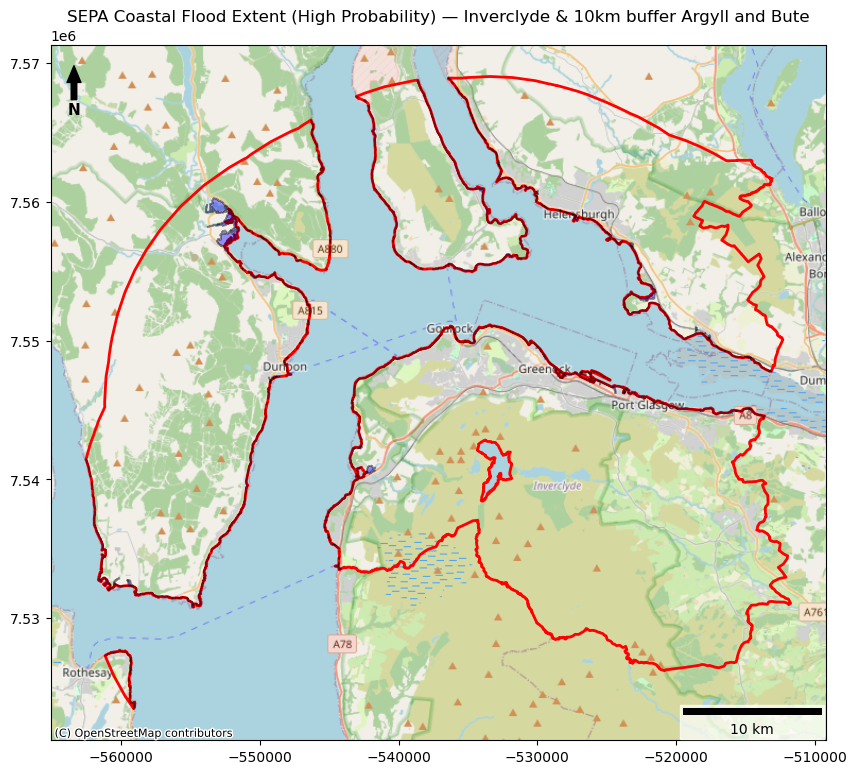

In [ ]:
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt


study_area = gpd.read_file("study_area_10Kmbuffer_dissolved.shp")

# Read SEPA flood layer
gdf = gpd.read_file(
    "/Users/xrysa/Desktop/MSc_in_Urban_Analytics/Dissertation/DATA/SEPA_Coastal_Flood_Maps_v3_0/Data/FRM_Coastal_Flood_Hazard_Layers_v3_0.gdb",
    layer="FRM_FH_COASTAL_EXTENT_H",
    bbox=bbox
)
# Clip flood layer to study area
gdf = gdf.to_crs(study_area.crs)
gdf_clipped = gpd.clip(gdf, study_area)

# Keep only polygon/multipolygon geometries
gdf_clipped = gdf_clipped[gdf_clipped.geometry.type.isin(["Polygon", "MultiPolygon"])].copy()


# Save the clipped file 
gdf_clipped.to_file("sepa_coastal_clipped.shp")

# Reproject to Web Mercator for basemap
gdf_clipped = gdf_clipped.to_crs(epsg=3857)
study_area  = study_area.to_crs(epsg=3857)

# Plot
fig, ax = plt.subplots(figsize=(10, 10))
study_area.plot(ax=ax, color="none", edgecolor="red", linewidth=2)
gdf_clipped.plot(ax=ax, color="blue", alpha=0.4, edgecolor="black")
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
ax.add_artist(ScaleBar(1, units="m", location="lower right", box_alpha=0.7))
ax.annotate(
    "N", xy=(0.03, 0.97), xytext=(0.03, 0.90),
    xycoords="axes fraction",
    arrowprops=dict(facecolor="black", width=4, headwidth=10),
    ha="center", fontsize=11, fontweight="bold",
)
plt.title("SEPA Coastal Flood Extent (High Probability) — Inverclyde & 10km buffer Argyll and Bute")
plt.show()

In [ ]:
pip install matplotlib-scalebar

Note: you may need to restart the kernel to use updated packages.


## Sentinel -1 display

In [ ]:
pip install PyQt5

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 43.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.8/36.8 MB 54.6 MB/s  0:00:00 58.4 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [PyQt5]━━━━━━━━━━━━ 2/3 [PyQt5]
Note: you may need to restart the kernel to use updated packages.


Flood pixels (whole raster, un-dilated): 11,052   nodata=None
CRS AUDIT
  Flood raster (source): EPSG:3035 (read directly, no reprojection)
  Study area   (source): EPSG:27700 (OSGB36 / British National Grid)
  Target CRS:            EPSG:3035 (ETRS89 / LAEA Europe, equal-area)
Study area:                361.84 km2
Flood, whole raster:         1.11 km2  (11,052 px at 10 m)
Flood, within study area:    0.72 km2  (this is what is drawn)
Flood, outside AOI:          0.39 km2  (reported, not drawn)

Saved: flood_extent_map_epsg3035.png


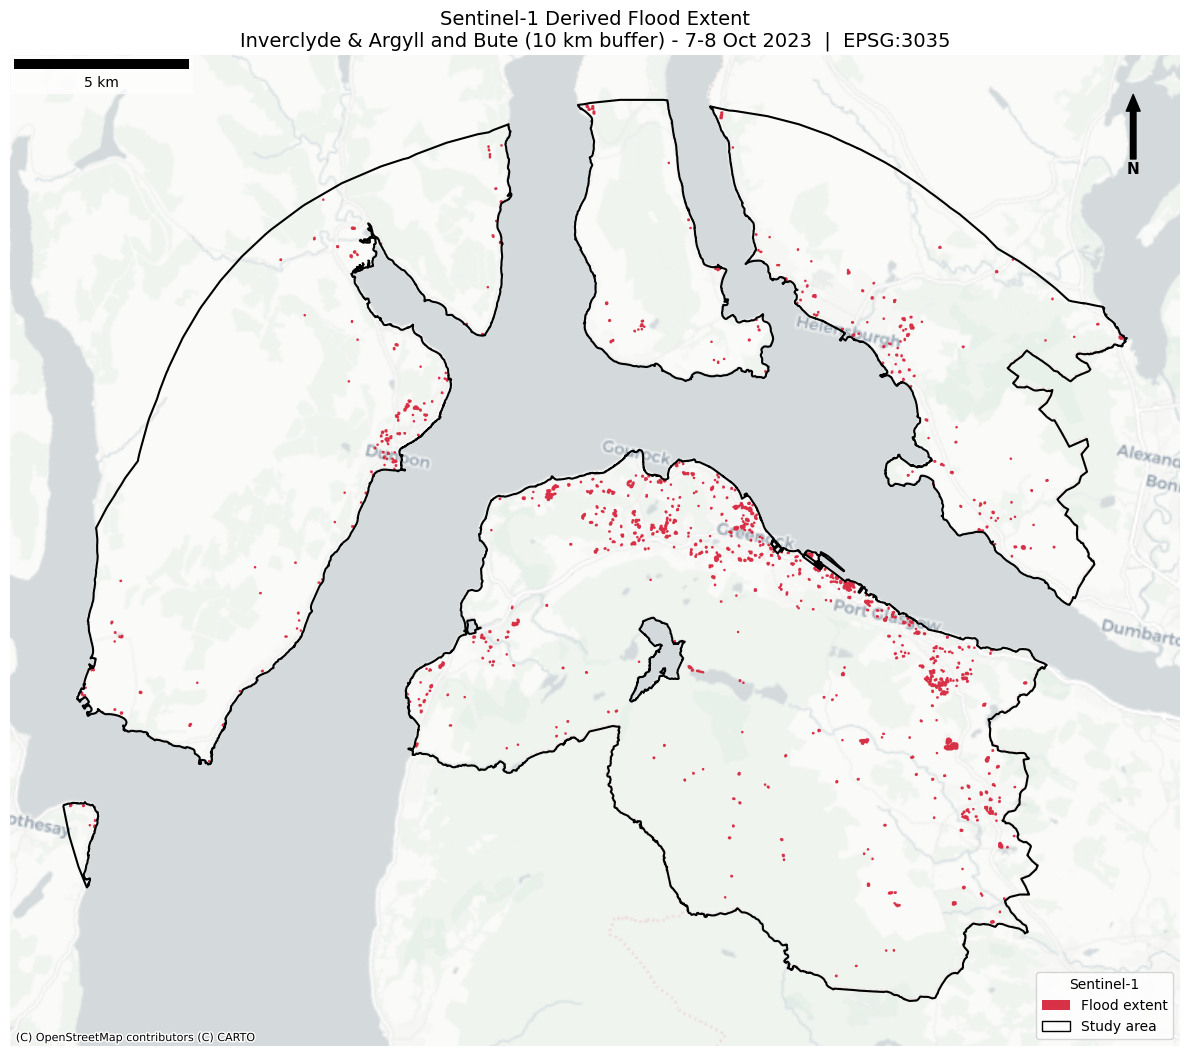

In [ ]:
"""
Sentinel-1 flood extent map, kept in EPSG:3035 (ETRS89 / LAEA Europe) to match
the SEPA flood-source overlay and the analysis CRS. No reprojection of the flood
raster: it is already 3035. Basemap tiles are reprojected into 3035 on the fly.

The displayed flood is clipped to the study area so the extent shown matches the
AOI-based figures in the results. Dilation is visual only.

"""

import numpy as np
import rasterio
from rasterio.features import shapes as rio_shapes
import geopandas as gpd
from shapely.geometry import shape
from shapely.ops import unary_union
import contextily as ctx
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib_scalebar.scalebar import ScaleBar

TARGET_CRS = "EPSG:3035"


# Input

BASE = "/Users/xrysa/Desktop/MSc_in_Urban_Analytics/Dissertation"
FLOOD_TIF = (f"{BASE}/DATA/Sentinel-1_StudyArea/"
             "StudyArea_flood_extent_oct2023_v5_slope30_buf50.tif")
STUDY_SHP = f"{BASE}/study_area_10Kmbuffer_dissolved.shp"
OUT_PNG = "flood_extent_map_epsg3035.png"

FLOOD_COLOR = "#D7263D"     # crimson - conventional flood/hazard colour
DILATE_BUFFER_M = 30        # visual buffer only, in metres

# Read the flood raster withiut reprojection as it is already EPSG:3035)
with rasterio.open(FLOOD_TIF) as src:
    if src.crs is None or src.crs.to_epsg() != 3035:
        raise RuntimeError(
            f"Flood raster is {src.crs}, expected EPSG:3035. This script assumes the "
            "source is already in the analysis CRS so that no resampling is needed."
        )
    band = src.read(1, masked=True)
    # GEE selfMask() writes nodata outside the flood; treat nodata and 0 alike.
    flood = (np.where(band.mask, 0, band.filled(0)) >= 1).astype(np.uint8)
    transform = src.transform
    src_nodata = src.nodata

n_flood = int(flood.sum())
print(f"Flood pixels (whole raster, un-dilated): {n_flood:,}   nodata={src_nodata}")
if n_flood == 0:
    raise RuntimeError("No flood pixels in the source raster - check the input.")

# Vectorise and clip to the study area  
geoms = [
    shape(g)
    for g, val in rio_shapes(flood, mask=flood.astype(bool), transform=transform)
    if val == 1
]
flood_gdf = gpd.GeoDataFrame(geometry=[unary_union(geoms)], crs=TARGET_CRS)

study_area = gpd.read_file(STUDY_SHP).to_crs(TARGET_CRS)

# Clip so the displayed extent matches the AOI-based numbers in the results.
flood_in_aoi = gpd.clip(flood_gdf, study_area)

area_total = flood_gdf.geometry.area.sum() / 1e6
area_in_aoi = flood_in_aoi.geometry.area.sum() / 1e6

# Visual dilation ONLY, on the clipped geometry.
flood_display = gpd.GeoDataFrame(
    geometry=[flood_in_aoi.union_all().buffer(DILATE_BUFFER_M)], crs=TARGET_CRS
)

# CRS audit
def _crs_label(gdf):
    if gdf.crs is None:
        return "UNDEFINED"
    epsg = gdf.crs.to_epsg()
    return f"EPSG:{epsg} ({gdf.crs.name})" if epsg else f"{gdf.crs.name} [no EPSG code]"

print("=" * 70)
print("CRS AUDIT")
print("=" * 70)
print("  Flood raster (source): EPSG:3035 (read directly, no reprojection)")
print(f"  Study area   (source): {_crs_label(gpd.read_file(STUDY_SHP))}")
print(f"  Target CRS:            {TARGET_CRS} (ETRS89 / LAEA Europe, equal-area)")
print("=" * 70)
print(f"Study area:              {study_area.geometry.area.sum() / 1e6:>8.2f} km2")
print(f"Flood, whole raster:     {area_total:>8.2f} km2  ({n_flood:,} px at 10 m)")
print(f"Flood, within study area:{area_in_aoi:>8.2f} km2  (this is what is drawn)")
print(f"Flood, outside AOI:      {area_total - area_in_aoi:>8.2f} km2  (reported, not drawn)")
print("=" * 70, "\n")

# Plot
fig, ax = plt.subplots(figsize=(12, 12))

flood_display.plot(ax=ax, color=FLOOD_COLOR, edgecolor="none", alpha=0.95, zorder=2)
study_area.boundary.plot(ax=ax, color="black", linewidth=1.5, zorder=4)

try:
    ctx.add_basemap(ax, crs=TARGET_CRS, source=ctx.providers.CartoDB.Positron)
except Exception as e:
    print(f"Basemap unavailable ({e}); plotting without it.")
    ax.set_facecolor("#f0f0f0")

# Legend, scale bar and North arrow 
legend_handles = [
    Patch(facecolor=FLOOD_COLOR, edgecolor="none", alpha=0.95, label="Flood extent"),
    Patch(facecolor="none", edgecolor="black", label="Study area"),
]
ax.legend(handles=legend_handles, loc="lower right", frameon=True, title="Sentinel-1")

# EPSG:3035 axis units are metres, so dx=1 is correct with no latitude correction.
ax.add_artist(ScaleBar(1, units="m", location="upper left", box_alpha=0.7))

ax.annotate(
    "N", xy=(0.96, 0.96), xytext=(0.96, 0.88),
    xycoords="axes fraction",
    arrowprops=dict(facecolor="black", width=4, headwidth=10),
    ha="center", fontsize=11, fontweight="bold",
)


ax.set_title(
    "Sentinel-1 Derived Flood Extent\n"
    "Inverclyde & Argyll and Bute (10 km buffer) - 7-8 Oct 2023  |  EPSG:3035",
    fontsize=14,
)
ax.set_axis_off()
plt.tight_layout()
plt.savefig(OUT_PNG, dpi=300, bbox_inches="tight")
print(f"Saved: {OUT_PNG}")


plt.show()

backend = matplotlib.get_backend()
if "agg" in backend.lower() and "inline" not in backend.lower():
    print(f"\n[display] active backend is '{backend}', which cannot open a window "
          "or render inline.\n"
          "          To see it on screen: `pip install PyQt5` then restart the "
          "session,\n"
          "          or open the saved PNG above.")

## SEPA display: Surface water, river, coastal
All layers reprojected to EPSG:3035 (ETRS89 / LAEA Europe) to match the
Sentinel-1 flood extent and to keep area-based statistics honest.

CRS AUDIT
  Study area (source): EPSG:27700 (OSGB36 / British National Grid)
  Surface    (source): EPSG:27700 (OSGB36 / British National Grid)
  River      (source): EPSG:27700 (OSGB36 / British National Grid)
  Coastal    (source): EPSG:27700 (OSGB36 / British National Grid)
  Target CRS:          EPSG:3035 (ETRS89 / LAEA Europe, equal-area)
After reprojection:
  Study area: EPSG:3035 (ETRS89-extended / LAEA Europe)
  Surface:    EPSG:3035 (ETRS89-extended / LAEA Europe)
  River:      EPSG:3035 (ETRS89-extended / LAEA Europe)
  Coastal:    EPSG:3035 (ETRS89-extended / LAEA Europe)

Study area:     361.8 km2
Surface:          9.4 km2
River:            8.2 km2
Coastal:          2.4 km2


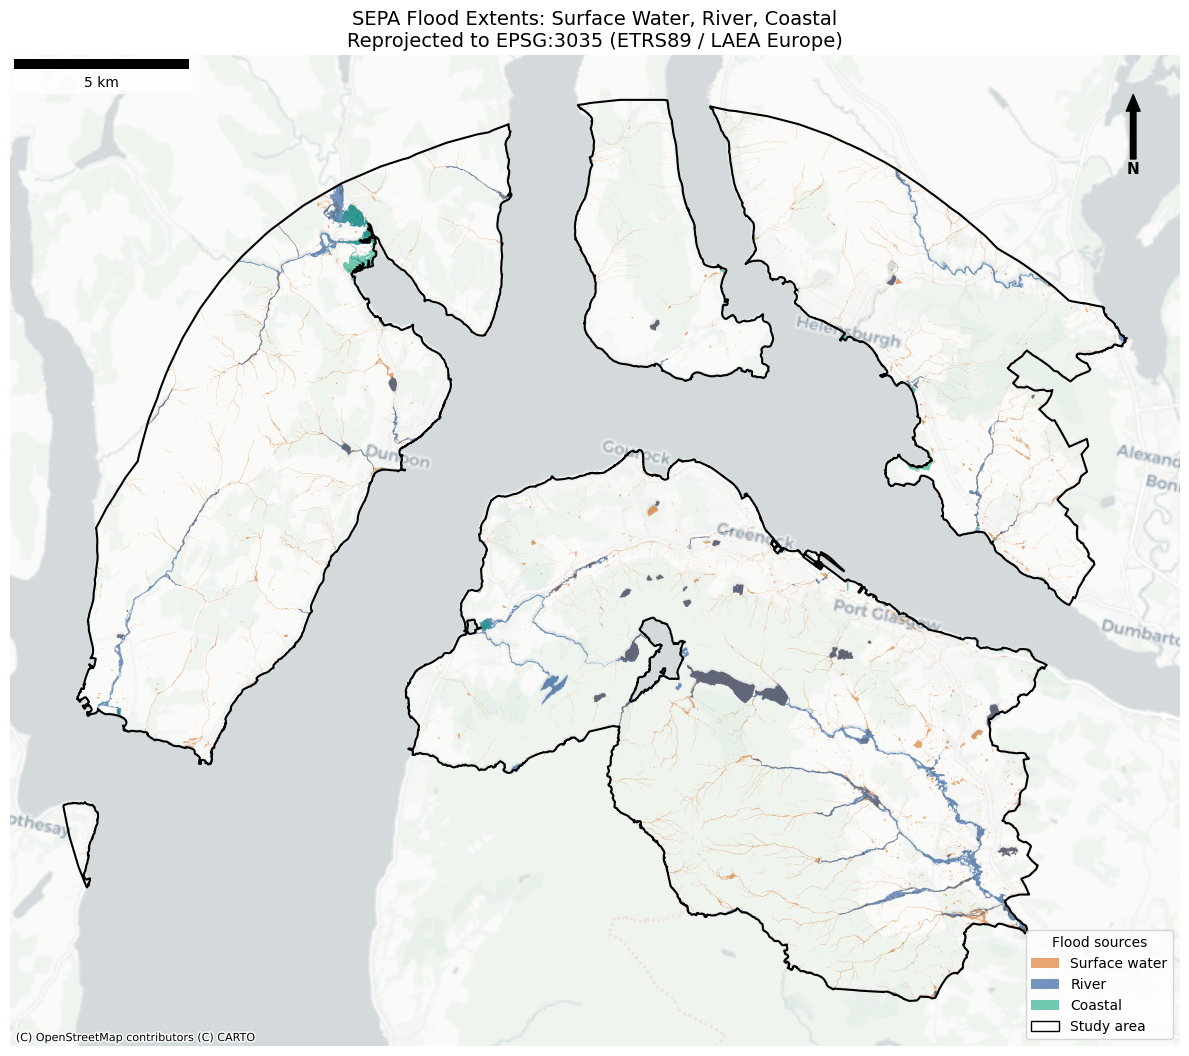

In [ ]:
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib_scalebar.scalebar import ScaleBar

TARGET_CRS = "EPSG:3035"

# Read saved study boundary and clipped flood layers
study_area = gpd.read_file("study_area_10Kmbuffer_dissolved.shp")
surface    = gpd.read_file("sepa_surface_water_clipped.shp")
river      = gpd.read_file("sepa_river_water_clipped.shp")
coastal    = gpd.read_file("sepa_coastal_water_clipped.shp")

#  Keep only polygon geometries
surface = surface[surface.geometry.type.isin(["Polygon", "MultiPolygon"])].copy()
river   = river[river.geometry.type.isin(["Polygon", "MultiPolygon"])].copy()
coastal = coastal[coastal.geometry.type.isin(["Polygon", "MultiPolygon"])].copy()

# Reproject every layer directly to EPSG:3035

# Print each layer's source CRS BEFORE reprojection. Useful for
# the methods chapter and for spotting a mis-tagged shapefile (e.g. a SEPA download that ended up in a different CRS than expected).
def _crs_label(gdf):
    """Compact 'EPSG:xxxx (Name)' string, or a fallback if unauthoritative."""
    if gdf.crs is None:
        return "UNDEFINED"
    epsg = gdf.crs.to_epsg()
    name = gdf.crs.name
    return f"EPSG:{epsg} ({name})" if epsg else f"{name} [no EPSG code]"

print("=" * 70)
print("CRS AUDIT")
print("=" * 70)
print(f"  Study area (source): {_crs_label(study_area)}")
print(f"  Surface    (source): {_crs_label(surface)}")
print(f"  River      (source): {_crs_label(river)}")
print(f"  Coastal    (source): {_crs_label(coastal)}")
print(f"  Target CRS:          {TARGET_CRS} (ETRS89 / LAEA Europe, equal-area)")
print("=" * 70)


study_area = study_area.to_crs(TARGET_CRS)
surface    = surface.to_crs(TARGET_CRS)
river      = river.to_crs(TARGET_CRS)
coastal    = coastal.to_crs(TARGET_CRS)

# Confirm every layer is now in the target CRS.
print("After reprojection:")
print(f"  Study area: {_crs_label(study_area)}")
print(f"  Surface:    {_crs_label(surface)}")
print(f"  River:      {_crs_label(river)}")
print(f"  Coastal:    {_crs_label(coastal)}")
print("=" * 70, "\n")

# Quick check: Area is meaningful now (EPSG:3035 is equal-area.
print(f"Study area:  {study_area.geometry.area.sum() / 1e6:>8.1f} km2")
print(f"Surface:     {surface.geometry.area.sum() / 1e6:>8.1f} km2")
print(f"River:       {river.geometry.area.sum() / 1e6:>8.1f} km2")
print(f"Coastal:     {coastal.geometry.area.sum() / 1e6:>8.1f} km2")

#  Colours
surface_color = "#D55E00"   # orange-red
river_color   = "#023E8A"   # blue
coastal_color = "#009E73"   # green

#  Plot
fig, ax = plt.subplots(figsize=(12, 12))

surface.plot(ax=ax, color=surface_color, edgecolor="none", alpha=0.55, zorder=1)
river.plot(  ax=ax, color=river_color,   edgecolor="none", alpha=0.55, zorder=2)
coastal.plot(ax=ax, color=coastal_color, edgecolor="none", alpha=0.55, zorder=3)

study_area.boundary.plot(ax=ax, color="black", linewidth=1.5, zorder=4)

# Basemap: contextily reprojects CartoDB tiles into EPSG:3035 on the fly
# when I pass crs=TARGET_CRS. Slightly slower  but keeps the axes in the analysis CRS so nothing 
# gets distorted, and any downstream overlay reads clean coordinates.
try:
    ctx.add_basemap(ax, crs=TARGET_CRS, source=ctx.providers.CartoDB.Positron)
except Exception as e:
    print(f"Basemap unavailable ({e}); plotting without it.")
    ax.set_facecolor("#f0f0f0")

#  Legend, scale bar, north arrow
legend_handles = [
    Patch(facecolor=surface_color, edgecolor="none", alpha=0.55, label="Surface water"),
    Patch(facecolor=river_color,   edgecolor="none", alpha=0.55, label="River"),
    Patch(facecolor=coastal_color, edgecolor="none", alpha=0.55, label="Coastal"),
    Patch(facecolor="none", edgecolor="black", label="Study area"),
]
ax.legend(handles=legend_handles, loc="lower right",
          frameon=True, title="Flood sources")

# EPSG:3035 axis units are metres, so dx=1 is correct with no correction.
ax.add_artist(ScaleBar(1, units="m", location="upper left", box_alpha=0.7))

ax.annotate(
    "N", xy=(0.96, 0.96), xytext=(0.96, 0.88),
    xycoords="axes fraction",
    arrowprops=dict(facecolor="black", width=4, headwidth=10),
    ha="center", fontsize=11, fontweight="bold",
)


ax.set_title(
    "SEPA Flood Extents: Surface Water, River, Coastal\n"
    "Reprojected to EPSG:3035 (ETRS89 / LAEA Europe)",
    fontsize=14,
)
ax.set_axis_off()
plt.tight_layout()

plt.savefig("combined_flood_map_epsg3035.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
import geopandas as gpd
import pandas as pd

TARGET_CRS = "EPSG:3035"

layers = {
    "surface": "sepa_surface_water_clipped.shp",
    "river":   "sepa_river_water_clipped.shp",
    "coastal": "sepa_coastal_water_clipped.shp",
}

frames = []
for source, path in layers.items():
    gdf = gpd.read_file(path).to_crs(TARGET_CRS)
    gdf = gdf[gdf.geometry.type.isin(["Polygon", "MultiPolygon"])].copy()
    gdf["geometry"] = gdf.geometry.buffer(0)
    gdf = gdf[gdf.geometry.type.isin(["Polygon", "MultiPolygon"])].copy()

    out = gdf[["geometry"]].copy()
    out["source"] = source
    frames.append(out)
    print(f"{source}: {len(out)} polygons")

merged = gpd.GeoDataFrame(pd.concat(frames, ignore_index=True), crs=TARGET_CRS)

out_path = "/Users/xrysa/Desktop/MSc_in_Urban_Analytics/Dissertation/sepa_flood_merged_3035.shp"
merged.to_file(out_path)

print(merged.groupby("source").size())
print(f"Sum of layers: {merged.geometry.area.sum()/1e6:.2f} km2")
print(f"Union:         {merged.geometry.unary_union.area/1e6:.2f} km2")
print(f"Saved: {out_path}")

surface: 26510 polygons
river: 365 polygons
coastal: 1 polygons
source
coastal        1
river        365
surface    26510
dtype: int64
Sum of layers: 20.07 km2


<positron-console-cell-3>:31: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.


Union:         16.21 km2
Saved: /Users/xrysa/Desktop/MSc_in_Urban_Analytics/Dissertation/sepa_flood_merged_3035.shp


Loading from /Users/xrysa/Desktop/MSc_in_Urban_Analytics/Dissertation


  AOI area (sq km):                 361.84
  SEPA area within AOI (sq km):      16.21
  Detected flood (sq km):             0.72

--- Nodata audit (inside AOI) ---
                  raster                                            status  nodata_in_aoi  pct
                   flood                                  nodata read as 0              0  0.0
           coastalFringe                                  nodata read as 0              0  0.0
          permanentWater                                  nodata read as 0              0  0.0
                neverWet                                  nodata read as 0              0  0.0
terrainMask (from slope) nodata filled as 9999.0 deg (fails <30.0, REMOVE)              0  0.0

--- SEPA eligibility cascade ---
                                         stage  area_km2  marginal_loss_km2  marginal_loss_pct  retained_pct
                     Stage 0 - all SEPA extent    1

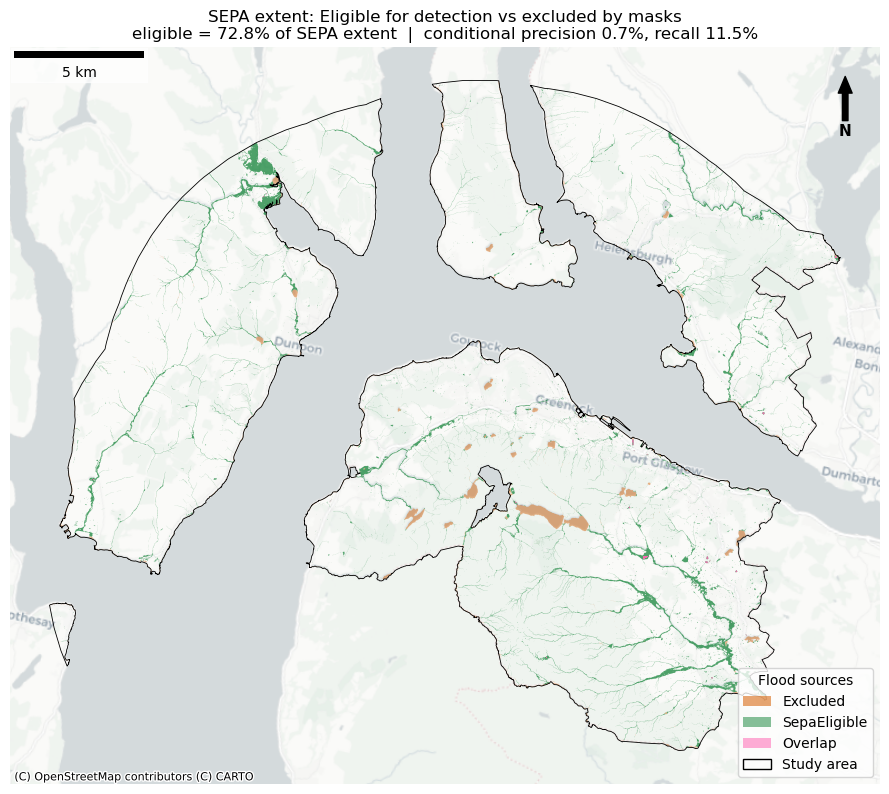

In [ ]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path

import contextily as ctx
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from matplotlib.patches import Patch
from matplotlib_scalebar.scalebar import ScaleBar
from rasterio.features import geometry_mask
from rasterio.features import shapes as rio_shapes
from shapely import make_valid
from shapely.geometry import Polygon, shape
from shapely.geometry.base import BaseGeometry
from shapely.ops import unary_union


DATA = Path("/Users/xrysa/Desktop/MSc_in_Urban_Analytics/Dissertation")
RASTER_DIR = DATA / "DATA" / "Sentinel-1_StudyArea"
OUT = DATA / "cascade_outputs"
OUT.mkdir(parents=True, exist_ok=True)

CRS = "EPSG:3035"
TARGET_CRS = CRS

COASTAL_BUFFER_METERS = 50
DEM_SLOPE_THRESHOLD = 30.0
GSW_OCCURRENCE_THRESHOLD = 50

SLOPE_PATH = RASTER_DIR / "StudyArea_slope_degrees.tif"
NODATA_SLOPE_FILL = 9999.0

GRID_SIZE = 0.01

VECTORS = {
    "sepa": DATA / "sepa_flood_merged_3035.shp",
    "aoi": DATA / "study_area_10Kmbuffer_dissolved.shp",
}

RASTERS = {
    "flood": {
        "path": RASTER_DIR / "StudyArea_flood_extent_oct2023_v5_slope30_buf50.tif",
        "nodata_as": 0,
    },
    "coastalFringe": {
        "path": RASTER_DIR / f"StudyArea_coastal_fringe_{COASTAL_BUFFER_METERS}m.tif",
        "nodata_as": 0,
    },
    "permanentWater": {
        "path": RASTER_DIR / "StudyArea_permanent_water.tif",
        "nodata_as": 0,
    },
    "neverWet": {
        "path": RASTER_DIR / "StudyArea_never_wet_refderived.tif",
        "nodata_as": 0,
    },
}

REQUIRED = ("sepa", "flood")


#  Geometry helpers

def to_polygonal(geom: BaseGeometry | None) -> BaseGeometry:
    if geom is None or geom.is_empty:
        return Polygon()
    if geom.geom_type in ("Polygon", "MultiPolygon"):
        return geom
    parts = [g for g in getattr(geom, "geoms", []) if g.geom_type in ("Polygon", "MultiPolygon")]
    return unary_union(parts) if parts else Polygon()


def _clean(geom_iter) -> BaseGeometry:
    geoms = [make_valid(g) if (g is not None and not g.is_valid) else g for g in geom_iter]
    geoms = [g for g in geoms if g is not None and not g.is_empty]
    return to_polygonal(unary_union(geoms)) if geoms else Polygon()


def intersect(a: BaseGeometry, b: BaseGeometry) -> BaseGeometry:
    if a.is_empty or b.is_empty:
        return Polygon()
    return to_polygonal(a.intersection(b, grid_size=GRID_SIZE))


def subtract(a: BaseGeometry, b: BaseGeometry) -> BaseGeometry:
    if a.is_empty:
        return Polygon()
    if b.is_empty:
        return a
    return to_polygonal(a.difference(b, grid_size=GRID_SIZE))


def area_km2(geom: BaseGeometry) -> float:
    return 0.0 if geom.is_empty else geom.area / 1e6


def _missing_msg(key: str, path: Path) -> str:
    folder = path.parent
    if folder.exists():
        found = sorted(p.name for p in folder.iterdir() if p.suffix.lower() in {".shp", ".tif"})
        listing = "\n  ".join(found) if found else "(no .shp or .tif files here)"
    else:
        listing = "(this folder does not exist)"
    return f"'{key}' not found at:\n  {path}\nFiles present in {folder}:\n  {listing}"


#  Loading functions

def load_vector(key: str, clip_to: BaseGeometry | None = None) -> BaseGeometry:
    path = VECTORS[key]
    if not path.exists():
        if key in REQUIRED:
            raise FileNotFoundError(_missing_msg(key, path))
        print(f"  [skipped] {key}: not found ({path.name})")
        return Polygon()

    gdf = gpd.read_file(path)
    if gdf.crs is None:
        raise ValueError(
            f"{path.name} has no .prj / CRS. Refusing to guess -- a wrong CRS here "
            f"silently rescales every area figure in the results."
        )
    geom = _clean(gdf.to_crs(CRS).geometry.values)
    return intersect(geom, clip_to) if clip_to is not None else geom


def polygonise(key: str, clip_to: BaseGeometry | None = None) -> BaseGeometry:
    if key not in RASTERS:
        raise KeyError(f"'{key}' is not in RASTERS. Defined keys: {sorted(RASTERS)}")

    spec = RASTERS[key]
    path, nodata_as = spec["path"], spec["nodata_as"]

    if not path.exists():
        if key in REQUIRED:
            raise FileNotFoundError(_missing_msg(key, path))
        print(f"  [skipped] {key}: not found ({path.name}) -- stage will show zero cost")
        return Polygon()

    with rasterio.open(path) as src:
        band = src.read(1, masked=True)
        arr = np.where(band.mask, nodata_as, band.filled(0))
        binary = (arr >= 1).astype(np.uint8)
        geoms = [
            shape(g)
            for g, val in rio_shapes(binary, mask=binary.astype(bool), transform=src.transform)
            if val == 1
        ]
        src_crs = src.crs

    if not geoms:
        return Polygon()

    geom = _clean(gpd.GeoDataFrame(geometry=geoms, crs=src_crs).to_crs(CRS).geometry.values)
    return intersect(geom, clip_to) if clip_to is not None else geom


def load_slope_mask(clip_to: BaseGeometry | None = None) -> BaseGeometry:
    if not SLOPE_PATH.exists():
        raise FileNotFoundError(_missing_msg("terrainMask (via slope)", SLOPE_PATH))

    with rasterio.open(SLOPE_PATH) as src:
        band = src.read(1, masked=True)
        arr = band.filled(NODATA_SLOPE_FILL)
        binary = (arr < DEM_SLOPE_THRESHOLD).astype(np.uint8)
        geoms = [
            shape(g)
            for g, val in rio_shapes(binary, mask=binary.astype(bool), transform=src.transform)
            if val == 1
        ]
        src_crs = src.crs

    if not geoms:
        return Polygon()

    geom = _clean(gpd.GeoDataFrame(geometry=geoms, crs=src_crs).to_crs(CRS).geometry.values)
    return intersect(geom, clip_to) if clip_to is not None else geom


def audit_nodata(aoi_geom: BaseGeometry) -> pd.DataFrame:
    rows = []
    for key, spec in RASTERS.items():
        path = spec["path"]
        if not path.exists():
            rows.append({"raster": key, "status": "missing", "nodata_in_aoi": None, "pct": None})
            continue
        with rasterio.open(path) as src:
            band = src.read(1, masked=True)
            aoi_src = (
                gpd.GeoSeries([aoi_geom], crs=CRS).to_crs(src.crs).iloc[0]
                if src.crs and str(src.crs) != CRS
                else aoi_geom
            )
            inside = ~geometry_mask(
                [aoi_src], out_shape=band.shape, transform=src.transform, invert=False
            )
            n_inside = int(inside.sum())
            n_nodata = int((band.mask & inside).sum()) if np.ndim(band.mask) else 0
        rows.append(
            {
                "raster": key,
                "status": f"nodata read as {spec['nodata_as']}",
                "nodata_in_aoi": n_nodata,
                "pct": round(n_nodata / n_inside * 100, 4) if n_inside else None,
            }
        )

    if SLOPE_PATH.exists():
        with rasterio.open(SLOPE_PATH) as src:
            band = src.read(1, masked=True)
            aoi_src = (
                gpd.GeoSeries([aoi_geom], crs=CRS).to_crs(src.crs).iloc[0]
                if src.crs and str(src.crs) != CRS
                else aoi_geom
            )
            inside = ~geometry_mask(
                [aoi_src], out_shape=band.shape, transform=src.transform, invert=False
            )
            n_inside = int(inside.sum())
            n_nodata = int((band.mask & inside).sum()) if np.ndim(band.mask) else 0
        rows.append(
            {
                "raster": "terrainMask (from slope)",
                "status": f"nodata filled as {NODATA_SLOPE_FILL} deg (fails <{DEM_SLOPE_THRESHOLD}, REMOVE)",
                "nodata_in_aoi": n_nodata,
                "pct": round(n_nodata / n_inside * 100, 4) if n_inside else None,
            }
        )
    else:
        rows.append({"raster": "terrainMask (from slope)", "status": "missing", "nodata_in_aoi": None, "pct": None})

    return pd.DataFrame(rows)


# Build AOI, SEPA, and the masks
print(f"Loading from {DATA}\n")

sepaFull = load_vector("sepa")

if VECTORS["aoi"].exists():
    aoi = load_vector("aoi")
else:
    print("  [inferred] aoi: study boundary not found, using SEPA convex hull")
    aoi = sepaFull.convex_hull

sepaGeom = intersect(sepaFull, aoi)

flood = polygonise("flood", clip_to=aoi)
permanentWater = polygonise("permanentWater", clip_to=aoi)

neverWet = polygonise("neverWet", clip_to=aoi)
everWet = subtract(aoi, neverWet) if not neverWet.is_empty else Polygon()

coastalFringe = polygonise("coastalFringe", clip_to=aoi)
if coastalFringe.is_empty and not permanentWater.is_empty:
    print(f"  [derived] coastalFringe: buffering permanentWater by {COASTAL_BUFFER_METERS} m")
    coastalFringe = intersect(permanentWater.buffer(COASTAL_BUFFER_METERS), aoi)

terrainMask = load_slope_mask(clip_to=aoi)
steep = subtract(aoi, terrainMask) if not terrainMask.is_empty else Polygon()

print(f"\n  AOI area (sq km):             {area_km2(aoi):10.2f}")
print(f"  SEPA area within AOI (sq km): {area_km2(sepaGeom):10.2f}")
print(f"  Detected flood (sq km):       {area_km2(flood):10.2f}")

print("\n--- Nodata audit (inside AOI) ---")
nodata_report = audit_nodata(aoi)
print(nodata_report.to_string(index=False))


# The cascade: Masks applied one at a time, in pipeline order

@dataclass
class Stage:
    label: str
    geom: BaseGeometry


stage0 = sepaGeom
stage1 = subtract(stage0, permanentWater)
stage2 = subtract(stage1, everWet)
stage3 = subtract(stage2, coastalFringe)
stage4 = subtract(stage3, steep)

stages = [
    Stage("Stage 0 - all SEPA extent", stage0),
    Stage("Stage 1 - after permanent water mask", stage1),
    Stage("Stage 2 - after SAR reference-derived neverWet", stage2),
    Stage(f"Stage 3 - after {COASTAL_BUFFER_METERS}m coastal buffer", stage3),
    Stage(f"Stage 4 - after slope < {DEM_SLOPE_THRESHOLD:.0f} deg", stage4),
]

areas = [area_km2(s.geom) for s in stages]
n0, n4 = areas[0], areas[-1]

rows, prev = [], n0
for st, a in zip(stages, areas):
    rows.append(
        {
            "stage": st.label,
            "area_km2": round(a, 3),
            "marginal_loss_km2": round(prev - a, 3),
            "marginal_loss_pct": round((prev - a) / n0 * 100, 2) if n0 else 0.0,
            "retained_pct": round(a / n0 * 100, 2) if n0 else 0.0,
        }
    )
    prev = a

cascade = pd.DataFrame(rows)
print("\n--- SEPA eligibility cascade ---")
print(cascade.to_string(index=False))


# The eligible domain

eligibleDomain = subtract(
    subtract(subtract(subtract(aoi, permanentWater), everWet), coastalFringe), steep
)
sepaEligible = stage4

floodEligible = intersect(flood, eligibleDomain)

print(f"\n  Eligible domain across AOI (sq km): {area_km2(eligibleDomain):10.2f}")
print(f"  Detected flood inside it (sq km):   {area_km2(floodEligible):10.2f}")
if area_km2(flood) > 0:
    retained = area_km2(floodEligible) / area_km2(flood) * 100
    print(f"  Share of detected flood retained:   {retained:10.2f} %")
    if retained < 95:
        print(
            "  [warning] more than 5% of the detected flood lies OUTSIDE the eligible\n"
            "            domain. The flood raster and the mask rasters are probably from\n"
            "            different runs of the classifier -- check their export dates."
        )


# per-flood_type eligible layer, preserving attribution

def build_eligible_by_type(sepa_path: Path, aoi_geom: BaseGeometry,
                           eligible_domain_geom: BaseGeometry) -> gpd.GeoDataFrame:
    gdf = gpd.read_file(sepa_path)
    if gdf.crs is None:
        raise ValueError(f"{sepa_path.name} has no CRS.")
    if "source" not in gdf.columns:
        raise KeyError(
            f"'source' column not found in {sepa_path.name}. "
            f"Columns present: {list(gdf.columns)}"
        )
    gdf = gdf.to_crs(CRS)

    out_rows = []
    for ftype, sub in gdf.groupby("source"):
        raw_geom = _clean(sub.geometry.values)
        raw_geom = intersect(raw_geom, aoi_geom)
        if raw_geom.is_empty:
            continue
        elig_geom = intersect(raw_geom, eligible_domain_geom)
        if elig_geom.is_empty:
            print(f"  [note] source='{ftype}': entirely masked out (0 eligible)")
            continue
        a_raw = area_km2(raw_geom)
        a_elig = area_km2(elig_geom)
        out_rows.append(
            {
                "flood_type": ftype,
                "geometry": elig_geom,
                "area_raw_km2": round(a_raw, 3),
                "area_eligible_km2": round(a_elig, 3),
                "pct_eligible": round(a_elig / a_raw * 100, 2) if a_raw else 0.0,
            }
        )

    if not out_rows:
        raise RuntimeError("No source group survived masking -- check inputs.")

    return gpd.GeoDataFrame(out_rows, crs=CRS)


print("\n--- Per-flood_type eligibility ---")
sepa_eligible_by_type = build_eligible_by_type(VECTORS["sepa"], aoi, eligibleDomain)
print(
    sepa_eligible_by_type[["flood_type", "area_raw_km2", "area_eligible_km2", "pct_eligible"]]
    .to_string(index=False)
)


# Agreement metrics (pooled, all sources)

overlap = intersect(floodEligible, sepaEligible)
a_overlap = area_km2(overlap)
a_sepaElig = area_km2(sepaEligible)
a_floodElig = area_km2(floodEligible)

precision = a_overlap / a_sepaElig * 100 if a_sepaElig else 0.0   # of SEPA extent, observed by S1
recall = a_overlap / a_floodElig * 100 if a_floodElig else 0.0    # of S1 detections, modelled by SEPA
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

unionElig = to_polygonal(unary_union([floodEligible, sepaEligible]))
iou = a_overlap / area_km2(unionElig) * 100 if area_km2(unionElig) else 0.0

overlapRaw = intersect(flood, sepaGeom)
precisionRaw = area_km2(overlapRaw) / n0 * 100 if n0 else 0.0
recallRaw = area_km2(overlapRaw) / area_km2(flood) * 100 if area_km2(flood) else 0.0

eligiblePct = n4 / n0 * 100 if n0 else 0.0

summary = pd.DataFrame(
    [
        ("SEPA extent within AOI (sq km)", round(n0, 3)),
        ("SEPA eligible after masks (sq km)", round(a_sepaElig, 3)),
        ("Eligible share of SEPA extent (%) - PRECISION CEILING", round(eligiblePct, 2)),
        ("Eligible domain across whole AOI (sq km)", round(area_km2(eligibleDomain), 3)),
        ("Detected flood within AOI (sq km)", round(area_km2(flood), 3)),
        ("Detected flood within eligible domain (sq km)", round(a_floodElig, 3)),
        ("Overlap, both eligible-restricted (sq km)", round(a_overlap, 3)),
        ("PRECISION - conditional (overlap / SEPA eligible) %", round(precision, 2)),
        ("RECALL - conditional (overlap / S1 eligible) %", round(recall, 2)),
        ("F1 - conditional %", round(f1, 2)),
        ("IoU - conditional %", round(iou, 2)),
        ("PRECISION - raw, no masks (overlap / all SEPA) %", round(precisionRaw, 2)),
        ("RECALL - raw, no masks (overlap / all S1) %", round(recallRaw, 2)),
    ],
    columns=["metric", "value"],
)

print("\n--- Summary ---")
print(summary.to_string(index=False))
print(
    "\nReading the ceiling: precision cannot exceed "
    f"{eligiblePct:.1f}% against the FULL SEPA extent, because that is all the masks "
    "left visible.\nThe conditional precision above already removes that penalty."
)


# Exports

cascade.to_csv(OUT / "sepa_cascade_table.csv", index=False)
summary.to_csv(OUT / "sepa_cascade_summary.csv", index=False)
nodata_report.to_csv(OUT / "nodata_audit.csv", index=False)
sepa_eligible_by_type.drop(columns="geometry").to_csv(
    OUT / "sepa_eligible_by_type_areas.csv", index=False
)

gpkg = OUT / "sepa_eligibility.gpkg"
excluded = subtract(sepaGeom, sepaEligible)

for name, geom in [
    ("sepa_extent", sepaGeom),
    ("sepa_eligible", sepaEligible),
    ("sepa_excluded_by_masks", excluded),
    ("eligible_domain", eligibleDomain),
    ("flood_eligible", floodEligible),
    ("overlap", overlap),
    ("coastal_fringe", coastalFringe),
]:
    if geom.is_empty:
        continue
    gpd.GeoDataFrame({"layer": [name]}, geometry=[geom], crs=CRS).to_file(
        gpkg, layer=name, driver="GPKG"
    )

sepa_eligible_by_type.to_file(gpkg, layer="sepa_eligible_by_type", driver="GPKG")
print(f"\nWritten layer 'sepa_eligible_by_type' with {len(sepa_eligible_by_type)} rows")


# Methods figure

fig, ax = plt.subplots(figsize=(9, 9))
gpd.GeoSeries([aoi], crs=CRS).boundary.plot(ax=ax, color="black", linewidth=0.6)

for geom, colour, alpha in [
    (excluded, "#D55E00", 0.45),
    (sepaEligible, "#238B45", 0.80),
    (overlap, "#FF69B4", 0.92),
]:
    if not geom.is_empty:
        gpd.GeoSeries([geom], crs=CRS).plot(ax=ax, color=colour, alpha=alpha)

ax.set_title(
    "SEPA extent: Eligible for detection vs excluded by masks\n"
    f"eligible = {eligiblePct:.1f}% of SEPA extent  |  "
    f"conditional precision {precision:.1f}%, recall {recall:.1f}%"
)

try:
    ctx.add_basemap(ax, crs=TARGET_CRS, source=ctx.providers.CartoDB.Positron)
except Exception as e:
    print(f"Basemap unavailable ({e}); plotting without it.")
    ax.set_facecolor("#f0f0f0")

legend_handles = [
    Patch(facecolor="#D55E00", edgecolor="none", alpha=0.55, label="Excluded"),
    Patch(facecolor="#238B45", edgecolor="none", alpha=0.55, label="SepaEligible"),
    Patch(facecolor="#FF69B4", edgecolor="none", alpha=0.55, label="Overlap"),
    Patch(facecolor="none", edgecolor="black", label="Study area"),
]
ax.legend(handles=legend_handles, loc="lower right", frameon=True, title="Flood sources")

ax.add_artist(ScaleBar(1, units="m", location="upper left", box_alpha=0.7))

ax.annotate(
    "N", xy=(0.96, 0.96), xytext=(0.96, 0.88),
    xycoords="axes fraction",
    arrowprops=dict(facecolor="black", width=4, headwidth=10),
    ha="center", fontsize=11, fontweight="bold",
)

ax.set_axis_off()
fig.tight_layout()
fig.savefig(OUT / "fig_sepa_eligibility.png", dpi=300)
print(f"\nWritten to {OUT}")


# 9. GEE export dependencies
#   StudyArea_flood_extent_oct2023_v5_slope30_buf50.tif
#   StudyArea_never_wet_refderived.tif
#   StudyArea_permanent_water.tif
#   StudyArea_coastal_fringe_50m.tif
#   StudyArea_slope_degrees.tif


In [ ]:
gdf = gpd.read_file(DATA / "sepa_flood_merged_3035.shp")
print(gdf.columns.tolist())
print(gdf.crs)
if "flood_type" in gdf.columns:
    print(gdf["flood_type"].value_counts())

Exception ignored while calling GC callback <bound method IPythonKernel._clean_thread_parent_frames of <positron.positron_ipkernel.PositronIPyKernel object at 0x11028acf0>>:
Traceback (most recent call last):
  File "/Applications/Positron.app/Contents/Resources/app/extensions/positron-python/python_files/lib/ipykernel/py3/ipykernel/ipkernel.py", line 796, in _clean_thread_parent_frames
    active_threads = {thread.ident for thread in threading.enumerate()}
  File "/opt/anaconda3/envs/spatial-regression/lib/python3.14/threading.py", line 1520, in enumerate
    def enumerate():
KeyboardInterrupt: 


['source', 'geometry']
EPSG:3035


In [ ]:
import geopandas as gpd
s = gpd.read_file(VECTORS["sepa"])
print(s.crs, len(s))
print(s.drop(columns="geometry").head(20))     
for c in s.columns:
    if c != "geometry" and s[c].nunique() < 20:
        print(c, s[c].unique())

# Alignment check: These bounds should overlap substantially
print("aoi  ", [round(v) for v in aoi.bounds])
print("sepa ", [round(v) for v in sepaGeom.bounds])
print("flood", [round(v) for v in flood.bounds])

EPSG:3035 26876
     source
0   surface
1   surface
2   surface
3   surface
4   surface
5   surface
6   surface
7   surface
8   surface
9   surface
10  surface
11  surface
12  surface
13  surface
14  surface
15  surface
16  surface
17  surface
18  surface
19  surface
source <StringArray>
['surface', 'river', 'coastal']
Length: 3, dtype: str
aoi   [3386174, 3730385, 3416559, 3756126]
sepa  [3386174, 3730387, 3416559, 3756115]
flood [3386370, 3731090, 3416440, 3755970]


# Sensitivilty slope analysis
Does our 30° slope cutoff actually matter, and is it excluding real terrain or DSM noise?
This code takes a continuous slope raster, then sweeps some cutoff values (3° up to 46°) to see how much the "eligible" flood area changes depending on where you draw the line. The pipeline actually uses 30°, so the point is to check whether that choice is doing a lot of heavy lifting or not. If the eligible area swings wildly across thresholds, I report a range and justify the 30°; if it's stable, I note the number isn't fragile.

The second half is a check, testing whether the slope exclusion is really cutting steep terrain or just cutting flat urban ground where the DSM (GLO-30) has building artefacts inflating the slope. It does this by comparing how "urban" the removed area is versus the flood extent overall. If the removed bits are disproportionately urban, that's a red flag the mask is throwing away hazard ground for the wrong reason.


Slope raster: 2575 x 3039 px
Slope distribution (deg): median 6.4, p75 10.9, p90 17.1, p99 31.2
(Sanity check: this should match the min/max/median printed by the GEE script's own slope check. If it doesn't, this .tif is not the current v6/v7 export.)
   3 deg -> ceiling 31.95%
   5 deg -> ceiling 46.15%
  10 deg -> ceiling 63.37%
  15 deg -> ceiling 69.37%
  20 deg -> ceiling 71.66%
  25 deg -> ceiling 72.51%
  29 deg -> ceiling 72.80%
  30 deg -> ceiling 72.85%  <-- pipeline value
  35 deg -> ceiling 72.96%
  40 deg -> ceiling 73.00%
  46 deg -> ceiling 73.01%

--- Slope threshold sensitivity ---
 slope_threshold_deg  sepa_eligible_km2  ceiling_%  slope_cost_km2  slope_cost_%_of_sepa
                   3              5.178      31.95           7.307                 45.08
                   5              7.480      46.15           5.005                 30.88
                  10             10.272      63.37           2.214                 13.66
                  15             11.24

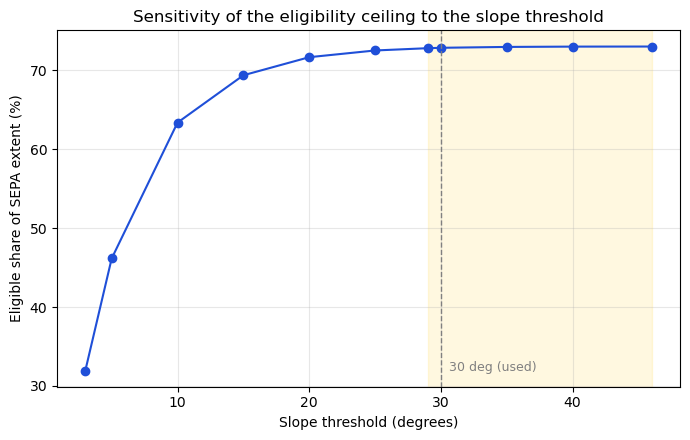

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from rasterio.features import shapes as rio_shapes
from shapely.geometry import Polygon, shape

SLOPE_PATH = RASTER_DIR / "StudyArea_slope_degrees.tif"
URBAN_PATH = RASTER_DIR / "StudyArea_urban_flag_80pct.tif"


PIPELINE_THRESHOLD_DEG = 30


THRESHOLDS = [3, 5, 10, 15, 20, 25, 29, 30, 35, 40, 46]

if not SLOPE_PATH.exists():
    raise FileNotFoundError(
        f"Continuous slope raster not found at:\n  {SLOPE_PATH}\n"
        "Re-run the v6/v7 GEE script (section 14 export) and download it -- do NOT use "
        "the Part 1 snippet above, it predates the EPSG:3035 reprojection fix."
    )


with rasterio.open(SLOPE_PATH) as src:
    slope_band = src.read(1, masked=True)
    slope_arr = slope_band.filled(np.nan)
    slope_transform = src.transform
    slope_crs = src.crs

print(f"Slope raster: {slope_arr.shape[0]} x {slope_arr.shape[1]} px")
valid = slope_arr[~np.isnan(slope_arr)]
print(
    f"Slope distribution (deg): median {np.median(valid):.1f}, "
    f"p75 {np.percentile(valid, 75):.1f}, p90 {np.percentile(valid, 90):.1f}, "
    f"p99 {np.percentile(valid, 99):.1f}"
)
print(
    f"(Sanity check: this should match the min/max/median printed by the GEE script's "
    f"own slope check. If it doesn't, this .tif is not the current v6/v7 export.)"
)


def steep_geom(threshold_deg: float):
    """Dissolved polygon of everything at or above the given slope, clipped to AOI."""
    binary = (np.nan_to_num(slope_arr, nan=9999) >= threshold_deg).astype(np.uint8)
    if binary.sum() == 0:
        return Polygon()
    geoms = [
        shape(g)
        for g, v in rio_shapes(binary, mask=binary.astype(bool), transform=slope_transform)
        if v == 1
    ]
    if not geoms:
        return Polygon()
    g = _clean(gpd.GeoDataFrame(geometry=geoms, crs=slope_crs).to_crs(CRS).geometry.values)
    return intersect(g, aoi)


#  Sweep the threshold through the cascade

stage3_fixed = stage3       
n0_fixed = area_km2(stage0)
a_stage3 = area_km2(stage3_fixed)

rows = []
steep_by_thresh = {}

for t in THRESHOLDS:
    st = steep_geom(t)
    steep_by_thresh[t] = st
    elig = subtract(stage3_fixed, st)
    a_elig = area_km2(elig)
    rows.append(
        {
            "slope_threshold_deg": t,
            "sepa_eligible_km2": round(a_elig, 3),
            "ceiling_%": round(a_elig / n0_fixed * 100, 2) if n0_fixed else 0.0,
            "slope_cost_km2": round(a_stage3 - a_elig, 3),
            "slope_cost_%_of_sepa": round((a_stage3 - a_elig) / n0_fixed * 100, 2) if n0_fixed else 0.0,
        }
    )
    marker = "  <-- pipeline value" if t == PIPELINE_THRESHOLD_DEG else ""
    print(f"  {t:>2} deg -> ceiling {rows[-1]['ceiling_%']:.2f}%{marker}")

sweep = pd.DataFrame(rows)
print("\n--- Slope threshold sensitivity ---")
print(sweep.to_string(index=False))
sweep.to_csv(OUT / "slope_sensitivity.csv", index=False)

if PIPELINE_THRESHOLD_DEG not in steep_by_thresh:
    raise ValueError(
        f"PIPELINE_THRESHOLD_DEG = {PIPELINE_THRESHOLD_DEG} is not in THRESHOLDS. "
        "Add it to THRESHOLDS so section 3 can reuse the already-computed geometry."
    )

span = sweep["ceiling_%"].max() - sweep["ceiling_%"].min()
print(f"\n  Ceiling range across {THRESHOLDS[0]}-{THRESHOLDS[-1]} deg: {span:.1f} percentage points")
if span > 15:
    print(
        "  The ceiling is highly sensitive to this parameter. Report it as a RANGE and\n"
        f"  justify the {PIPELINE_THRESHOLD_DEG} deg choice explicitly -- a point estimate would be misleading."
    )
else:
    print(
        "  The ceiling is reasonably stable across plausible thresholds, which is worth\n"
        f"  stating: the {PIPELINE_THRESHOLD_DEG} deg choice is not load-bearing for the headline figure."
    )

# DSM Artefact test 
# # If GLO-30 building artifacts are causing the slope exclusion, the removed
# flood area should be more urban than the flood overall. I compare the two urban
# sharesm their ratio measures how strong the effect is. 


if not URBAN_PATH.exists():
    print(f"\n  [skipped] DSM artefact test: urban flag raster not found at {URBAN_PATH.name}")
else:
    with rasterio.open(URBAN_PATH) as src:
        band = src.read(1, masked=True)
        binary = (np.where(band.mask, 0, band.filled(0)) >= 1).astype(np.uint8)
        geoms = [
            shape(g)
            for g, v in rio_shapes(binary, mask=binary.astype(bool), transform=src.transform)
            if v == 1
        ]
        ucrs = src.crs
    urban = (
        intersect(_clean(gpd.GeoDataFrame(geometry=geoms, crs=ucrs).to_crs(CRS).geometry.values), aoi)
        if geoms
        else Polygon()
    )

    steep_pipeline = steep_by_thresh[PIPELINE_THRESHOLD_DEG]
    removed_by_slope = intersect(stage3_fixed, steep_pipeline)  # SEPA area the pipeline cut removes

    a_removed = area_km2(removed_by_slope)
    a_removed_urban = area_km2(intersect(removed_by_slope, urban))
    a_sepa_urban = area_km2(intersect(sepaGeom, urban))

    share_removed = a_removed_urban / a_removed * 100 if a_removed else 0.0
    share_baseline = a_sepa_urban / n0_fixed * 100 if n0_fixed else 0.0

    print(f"\n--- DSM building-artefact test ({PIPELINE_THRESHOLD_DEG} deg cut) ---")
    print(f"  SEPA area removed by slope cut:        {a_removed:8.3f} km2")
    print(f"  ... of which urban (>80% impervious):  {a_removed_urban:8.3f} km2  ({share_removed:.1f}%)")
    print(f"  Urban share of the SEPA extent overall:{share_baseline:8.1f} %")
    if share_baseline > 0:
        ratio = share_removed / share_baseline
        print(f"  Enrichment ratio:                      {ratio:8.2f}x")
        if ratio > 1.5:
            print(
                "\n  Slope exclusion is concentrated in built-up ground well beyond its share\n"
                "  of the extent. Consistent with GLO-30 building returns generating\n"
                "  artificial slope on flat urban frontage. Report this: it means the mask\n"
                "  is removing hazard ground for a reason unrelated to real terrain, and it\n"
                "  justifies either a lower threshold or excluding urban pixels from the\n"
                "  slope test altogether."
            )
        else:
            print(
                "\n  No meaningful urban concentration. The slope exclusion reflects genuine\n"
                "  terrain, not DSM artefacts -- which is itself worth stating, since it\n"
                "  closes off an obvious objection. Note the 30 deg threshold is already\n"
                "  motivated by sensor geometry (S1 IW layover, 29-46 deg incidence), not\n"
                "  chosen to fit the terrain, which strengthens this reading."
            )

# Plot
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(sweep["slope_threshold_deg"], sweep["ceiling_%"], marker="o", color="#1f4fd8")
ax.axvline(PIPELINE_THRESHOLD_DEG, color="#808080", linestyle="--", linewidth=1)
ax.annotate(
    f"{PIPELINE_THRESHOLD_DEG} deg (used)",
    xy=(PIPELINE_THRESHOLD_DEG, sweep["ceiling_%"].min()),
    xytext=(PIPELINE_THRESHOLD_DEG + 0.6, sweep["ceiling_%"].min()),
    color="#808080", fontsize=9
)
# Shade the S1 IW layover/shadow incidence-angle range for context
ax.axvspan(29, 46, color="#ffcc00", alpha=0.12)
ax.set_xlabel("Slope threshold (degrees)")
ax.set_ylabel("Eligible share of SEPA extent (%)")
ax.set_title("Sensitivity of the eligibility ceiling to the slope threshold")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(OUT / "fig_slope_sensitivity.png", dpi=300)
print(f"\nWritten to {OUT}")

The code below takes the final Sentinel-1 flood raster (October 2023 event over Inverclyde and Argyll & Bute), runs a thorough diagnostics pass on it, then produces a publication-quality map.

It interrogates the raster by hecking the file integrity, confirming it's projected in an equal-area CRS, counting how many pixels are flood vs nodata vs zero, computing the actual flood area in km², and flagginh anything suspicious (no flood pixels, non-binary values, a geographic CRS sneaking in, or a suspiciously large footprint that might be a leftover coastal artefact).

In [ ]:
import numpy as np
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from pyproj import CRS as PyprojCRS
from scipy.ndimage import binary_dilation
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from matplotlib_scalebar.scalebar import ScaleBar
import contextily as ctx

# Inputs 
FLOOD_TIF = ("/Users/xrysa/Desktop/MSc_in_Urban_Analytics/Dissertation/DATA/"
             "Sentinel-1_StudyArea/StudyArea_flood_extent_oct2023_v5_slope30_buf50.tif")
OUT_PNG = ("/Users/xrysa/Desktop/MSc_in_Urban_Analytics/Dissertation/DATA/"
           "Sentinel-1_StudyArea/StudyArea_FloodExtent_v6_map.png")

TARGET_CRS   = "EPSG:3035"
FLOOD_COLOR  = "#D7263D"    
DILATE_ITERS = 3             # ~30 m visual buffer for cartographic clarity


# Diagnostics 
def run_diagnostics(src, arr_raw):
    """Print raster diagnostics; return dict of derived values for plotting.

    arr_raw is the band exactly as read (float32), BEFORE any nodata/zero
    masking, so counts refer to what is actually stored on disk.
    """
    print("=" * 70)
    print("RASTER DIAGNOSTICS:", FLOOD_TIF.rsplit("/", 1)[-1])
    print("=" * 70)

    # Check File integrity 
    print("\n[File]")
    print("  driver:          ", src.driver)
    print("  band count:      ", src.count)
    print("  shape (rows,cols):", arr_raw.shape)
    print("  dtype (on disk): ", src.dtypes[0])
    print("  nodata tag:      ", src.nodata)

    #  Georeferencing 
    crs = src.crs
    px_w, px_h = abs(src.transform.a), abs(src.transform.e)
    print("\n[Georeferencing]")
    print("  CRS:             ", crs)
    print("  projected CRS:   ", crs.is_projected if crs else "UNKNOWN")
    print("  pixel size:      ", f"{px_w:.6g} x {px_h:.6g}",
          "(m)" if crs and crs.is_projected else "(deg)" if crs else "(?)")
    print("  bounds:          ", src.bounds)

    #  Check Value integrity
    n_total = arr_raw.size
    n_nan = int(np.isnan(arr_raw).sum())
    finite = arr_raw[np.isfinite(arr_raw)]
    n_nodata = int((finite == src.nodata).sum()) if src.nodata is not None else 0
    n_zero = int((finite == 0).sum())
    n_one = int((finite == 1).sum())
    uniq = np.unique(finite)
    uniq_str = (", ".join(f"{v:g}" for v in uniq[:10])
                + (" ..." if uniq.size > 10 else ""))

    print("\n[Values]")
    print("  raw min / max:   ",
          f"{np.nanmin(arr_raw):g} / {np.nanmax(arr_raw):g}" if finite.size else "all NaN")
    print("  unique values:   ", uniq_str, f"({uniq.size} distinct)")
    print(f"  NaN:              {n_nan:>12,} / {n_total:,} "
          f"({100 * n_nan / n_total:.2f}%)")
    print(f"  == nodata tag:    {n_nodata:>12,} / {n_total:,} "
          f"({100 * n_nodata / n_total:.2f}%)")
    print(f"  == 0:             {n_zero:>12,} / {n_total:,} "
          f"({100 * n_zero / n_total:.2f}%)")
    print(f"  == 1 (flood):     {n_one:>12,} / {n_total:,} "
          f"({100 * n_one / n_total:.2f}%)")

    # Check Flood area 
    print("\n[Flood statistics]")
    if crs and crs.is_projected:
        pixel_area_m2 = px_w * px_h
        print(f"  pixel area:       {pixel_area_m2:g} m2 (projected CRS)")
    elif crs:
        lat_c = (src.bounds.top + src.bounds.bottom) / 2.0
        m_per_deg_lat = 111_320.0
        m_per_deg_lon = 111_320.0 * np.cos(np.deg2rad(lat_c))
        pixel_area_m2 = (px_w * m_per_deg_lon) * (px_h * m_per_deg_lat)
        print(f"  pixel area:       ~{pixel_area_m2:.1f} m2 "
              f"(approximated at lat {lat_c:.2f} - geographic CRS)")
    else:
        pixel_area_m2 = np.nan
        print("  pixel area:       UNKNOWN (no CRS)")

    flood_km2 = n_one * pixel_area_m2 / 1e6
    flood_ha = n_one * pixel_area_m2 / 1e4
    footprint_pct = 100 * n_one / n_total
    print(f"  flood pixels:     {n_one:,}")
    print(f"  flood area:       {flood_km2:.3f} km2  ({flood_ha:,.1f} ha)")
    print(f"  % of raster grid: {footprint_pct:.3f}%")

    # Warnings a
    print("\n[Sanity checks]")
    warned = False
    if n_one == 0:
        print("  !! No flood pixels found, wrong band, wrong file, or the"
              " classification returned empty.")
        warned = True
    unexpected = uniq[~np.isin(uniq, [0, 1] + ([src.nodata] if src.nodata is not None else []))]
    if unexpected.size:
        print(f"  !! Unexpected values present ({unexpected[:5]} ...):"
              " band should be binary (1 / nodata).")
        warned = True
    if crs and not crs.is_projected:
        print("  !! CRS is GEOGRAPHIC (degrees). Re-export from GEE with"
              " crs: 'EPSG:3035' for a clean product.")
        warned = True
    if footprint_pct > 5:
        print(f"  !! Flood covers {footprint_pct:.1f}% of the raster grid -"
              " unusually high; possible residual coastal artifact.")
        warned = True
    if not warned:
        print("  All checks passed.")
    print("=" * 70, "\n")

    return {"flood_km2": flood_km2, "flood_ha": flood_ha, "n_flood": n_one}


# Raed, diagnose and reporject to EPSG:3035
with rasterio.open(FLOOD_TIF) as src:
    # Read as a masked array so nodata is known explicitly, rather
    # than reading the raw band and relying on values happening to be 0/NaN.
    band_masked = src.read(1, masked=True)
    arr_raw = band_masked.filled(np.nan).astype("float32")

    # Run diagnostics on the source raster (before any reprojection).
    # if the source is EPSG:3035, this is the correct equal-area figure.
    diag = run_diagnostics(src, arr_raw)

    src_crs_pp = PyprojCRS.from_user_input(src.crs)
    src_crs_label = (f"EPSG:{src_crs_pp.to_epsg()}"
                     if src_crs_pp.to_epsg() else src_crs_pp.name)

    # If the source is already in EPSG:3035, skip the warp entirely.
    if src.crs and src.crs.to_epsg() == 3035:
        print("Source already in EPSG:3035 - skipping reprojection.\n")
        # Eplicitly fill to 0 for nodata, then cast, instead of a raw cast
        # of the unmasked float band. A raw cast is only safe if nodata is
        # exactly 0 or NaN. This is safe regardless of the nodata tag used.
        dst = band_masked.filled(0).astype(np.uint8)
        transform = src.transform
        width, height = src.width, src.height
    else:
        print(f"Reprojecting {src_crs_label} -> {TARGET_CRS}...")
        transform, width, height = calculate_default_transform(
            src.crs, TARGET_CRS, src.width, src.height, *src.bounds
        )
        dst = np.zeros((height, width), dtype=np.uint8)
        reproject(
            source=rasterio.band(src, 1),
            destination=dst,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs=TARGET_CRS,
            resampling=Resampling.nearest,  # binary layer -> nearest only
            src_nodata=src.nodata,
            dst_nodata=0,
        )
        print(f"Reprojected. Flood pixels after warp: {int((dst == 1).sum()):,}\n")

    left, top = transform.c, transform.f
    right = left + transform.a * width
    bottom = top + transform.e * height
    extent = (left, right, bottom, top)


# Dispaly mask i.e., dilate for cartographic visibility

flood_binary = (dst == 1)
if DILATE_ITERS > 0:
    flood_display = binary_dilation(flood_binary, iterations=DILATE_ITERS)
else:
    flood_display = flood_binary
flood_masked = np.ma.masked_where(~flood_display,
                                  flood_display.astype(np.uint8))


# Plot
fig, ax = plt.subplots(figsize=(10, 10), dpi=200)

ax.imshow(
    flood_masked,
    extent=extent,
    origin="upper",
    cmap=ListedColormap([FLOOD_COLOR]),
    alpha=0.95,
    interpolation="nearest",
    zorder=2,
)

try:
    # contextily reprojects Web Mercator tiles into EPSG:3035 on the fly.
    ctx.add_basemap(ax, crs=TARGET_CRS,
                    source=ctx.providers.CartoDB.Positron, zoom="auto")
    for artist in ax.get_images():
        if not np.ma.isMaskedArray(artist.get_array()):
            artist.set_zorder(0)
except Exception as e:
    print(f"Basemap unavailable ({e}); plotting without it.")
    ax.set_facecolor("#f0f0f0")

ax.set_xlim(extent[0], extent[1])
ax.set_ylim(extent[2], extent[3])
ax.set_xticks([]); ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title(
    "Sentinel-1 Derived Flood Extent\n"
    "Inverclyde & Argyll and Bute (10 km buffer) – 7–8 Oct 2023",
    fontsize=13, pad=12,
)

# Legend with area from diagnostics.
legend_elements = [
    Patch(facecolor=FLOOD_COLOR, edgecolor="none", alpha=0.95,
          label=f"Flood extent ({diag['flood_km2']:.2f} km$^2$)")
]
ax.legend(handles=legend_elements, loc="upper left",
          frameon=True, fontsize=10)

# EPSG:3035 axis units are metres, so dx=1 is exact - no correction needed
ax.add_artist(ScaleBar(1, units="m", location="upper right", box_alpha=0.7))

# North arrow: middle-right of the map, between scale bar and CRS label.
ax.annotate(
    "N", xy=(0.97, 0.55), xytext=(0.97, 0.47),
    xycoords="axes fraction",
    arrowprops=dict(facecolor="black", width=4, headwidth=10),
    ha="center", fontsize=11, fontweight="bold",
)

# CRS annotation on the figure
ax.text(
    0.99, 0.01,
    f"CRS: {TARGET_CRS} (source: {src_crs_label})",
    transform=ax.transAxes, ha="right", va="bottom",
    fontsize=8, color="black",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", pad=2),
)


fig.text(
    0.01, 0.01,
    "Data: Sentinel-1 GRD (Copernicus), GEE-derived Otsu threshold flood "
    f"classification (source CRS {src_crs_label}). Flood pixels dilated by "
    "~30 m for visual clarity; area statistics computed from un-dilated "
    "raster. Basemap: OpenStreetMap contributors.",
    fontsize=6, color="grey", wrap=True,
)

plt.tight_layout()
plt.savefig(OUT_PNG, dpi=200, bbox_inches="tight")
print(f"Saved: {OUT_PNG}")
plt.show()

RASTER DIAGNOSTICS: StudyArea_flood_extent_oct2023_v5_slope30_buf50.tif

[File]
  driver:           GTiff
  band count:       1
  shape (rows,cols): (2575, 3039)
  dtype (on disk):  uint8
  nodata tag:       None

[Georeferencing]
  CRS:              EPSG:3035
  projected CRS:    True
  pixel size:       10 x 10 (m)
  bounds:           BoundingBox(left=3386260.0, bottom=3730450.0, right=3416650.0, top=3756200.0)

[Values]
  raw min / max:    0 / 1
  unique values:    0, 1 (2 distinct)
  NaN:                         0 / 7,825,425 (0.00%)
  == nodata tag:               0 / 7,825,425 (0.00%)
  == 0:                7,814,373 / 7,825,425 (99.86%)
  == 1 (flood):           11,052 / 7,825,425 (0.14%)

[Flood statistics]
  pixel area:       100 m2 (projected CRS)
  flood pixels:     11,052
  flood area:       1.105 km2  (110.5 ha)
  % of raster grid: 0.141%

[Sanity checks]
  All checks passed.

Source already in EPSG:3035 - skipping reprojection.

Saved: /Users/xrysa/Desktop/MSc_in_Urban_Anal

<positron-console-cell-69>:308: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


In [ ]:
import geopandas as gpd
gpkg = OUT / "sepa_eligibility.gpkg"

sepa_elig  = gpd.read_file(gpkg, layer="sepa_eligible")
flood_elig = gpd.read_file(gpkg, layer="flood_eligible")
overlap    = gpd.read_file(gpkg, layer="overlap")


The code below merges the three SEPA flood-hazard map layers (surface water, river, and coastal flooding) into a single tidy dataset so downstream steps have a single source-of-truth flood dataset to work against.

In [ ]:
import pandas as pd
import geopandas as gpd

TARGET_CRS = "EPSG:3035"

# Load the three SEPA layers
surface = gpd.read_file("sepa_surface_water_clipped.shp")
river   = gpd.read_file("sepa_river_water_clipped.shp")
coastal = gpd.read_file("sepa_coastal_water_clipped.shp")

# Keep only polygons
surface = surface[surface.geometry.type.isin(["Polygon", "MultiPolygon"])].copy()
river   = river[river.geometry.type.isin(["Polygon", "MultiPolygon"])].copy()
coastal = coastal[coastal.geometry.type.isin(["Polygon", "MultiPolygon"])].copy()

# Reproject to EPSG:3035
surface = surface.to_crs(TARGET_CRS)
river   = river.to_crs(TARGET_CRS)
coastal = coastal.to_crs(TARGET_CRS)

# Tag each layer with its source type
surface["flood_type"] = "surface"
river["flood_type"]   = "river"
coastal["flood_type"] = "coastal"

# Merge into one GeoDataFrame
sepa_all = gpd.GeoDataFrame(
    pd.concat([surface, river, coastal], ignore_index=True),
    crs=TARGET_CRS,
)

# Save
sepa_all.to_file("sepa_all_flood_epsg3035.shp")
print(f"Saved: sepa_all_flood_epsg3035.shp ({len(sepa_all):,} polygons)")

Saved: sepa_all_flood_epsg3035.shp (26,876 polygons)


The code below carves my study area out of the Europe-wide imperviousness raster so I've got a small, local file to work with instead of the whole continent around.

In [ ]:
import geopandas as gpd
import rasterio
from rasterio.mask import mask

HRL_TIF        = "/Users/xrysa/Desktop/MSc_in_Urban_Analytics/Dissertation/DATA/HRL_imperviousness/Results/IMD_2018_010m_eu_03035_v020/DATA/IMD_2018_010m_eu_03035_V2_0.tif"
STUDY_BOUNDARY = "study_area_10Kmbuffer_dissolved.shp"
OUT_TIF        = "/Users/xrysa/Desktop/MSc_in_Urban_Analytics/Dissertation/DATA/StudyArea_hrl_imperviousness_2018.tif"

aoi = gpd.read_file(STUDY_BOUNDARY).to_crs("EPSG:3035")

with rasterio.open(HRL_TIF) as src:
    out_image, out_transform = mask(src, aoi.geometry, crop=True)
    out_meta = src.meta.copy()

out_meta.update({
    "height": out_image.shape[1],
    "width":  out_image.shape[2],
    "transform": out_transform,
})

with rasterio.open(OUT_TIF, "w", **out_meta) as dst:
    dst.write(out_image)

print(f"Saved: {OUT_TIF}")

Saved: /Users/xrysa/Desktop/MSc_in_Urban_Analytics/Dissertation/DATA/StudyArea_hrl_imperviousness_2018.tif


In [ ]:
import fiona
print(fiona.listlayers("/Users/xrysa/Desktop/MSc_in_Urban_Analytics/Dissertation/cascade_outputs/sepa_eligibility.gpkg"))

['sepa_extent', 'sepa_eligible', 'sepa_excluded_by_masks', 'eligible_domain', 'flood_eligible', 'overlap', 'coastal_fringe', 'sepa_eligible_by_type']
